# Credit Risk & Loan Repayment Prediction

## 1. Introducción y objetivo

Este notebook desarrolla modelos para estimar, a partir de las características del préstamo, la probabilidad de que un préstamo histórico de LendingClub **no se pague completamente**. El conjunto utilizado corresponde a préstamos concedidos entre 2007 y 2010; por su antigüedad, sus resultados no deben extrapolarse automáticamente al mercado actual.

La variable objetivo es `not.fully.paid`: **0** indica que el préstamo se pagó completamente y **1** que no se pagó completamente. En los datos del EDA, la clase positiva representa aproximadamente el 16 % de los registros. Por ello, accuracy no es suficiente: se estudiarán en particular recall, precision, F1, ROC-AUC, PR-AUC y la calibración de las probabilidades.

El objetivo es comparar familias de modelos y tratamientos del desbalance de manera reproducible, sin usar el test para seleccionar modelos. Las conclusiones se escriben en Markdown después de ejecutar los análisis, de modo que se puedan editar.

### Objetivo del modelado

Se compararán un baseline, regresión logística, Random Forest y XGBoost, incluyendo alternativas sin balanceo, con pesos de clase y con RandomOverSampler cuando sea metodológicamente apropiado. Se evaluarán tanto la clasificación con umbral predeterminado como la calidad de la probabilidad estimada de no pago completo. Ningún resultado de este ejercicio constituye una decisión crediticia real ni una probabilidad de incumplimiento regulatoria.

## 2. Importación de librerías

Se comprueban las dependencias necesarias antes de entrenar. Si falta alguna, el error indicará qué paquete instalar. SHAP se utilizará para interpretar XGBoost; el resto de las importaciones cubre la preparación, validación, evaluación y visualización.

In [1]:
import importlib.metadata
import importlib.util
import os
import platform
from pathlib import Path

required_modules = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "xgboost": "xgboost",
    "shap": "shap",
}
missing_packages = [
    package
    for module, package in required_modules.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    raise ImportError(
        "Faltan dependencias del proyecto: "
        + ", ".join(missing_packages)
        + ". Instálalas en el entorno del notebook antes de continuar."
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import scipy
import sklearn
import xgboost
from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbalancedPipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SEED = 42
TARGET = "not.fully.paid"
POSITIVE_LABEL = 1
TEST_SIZE = 0.20
THRESHOLD = 0.50

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", palette="colorblind")

## 3. Carga de los datos

Se busca el archivo `.env` y el CSV en la raíz del proyecto o sus carpetas habituales. Las variables `DATA_PATH`, `TARGET_COLUMN` y `RANDOM_STATE` se leen primero del entorno del sistema y después del `.env`; se usan valores predeterminados únicamente cuando no estén definidos. Esta carga no depende del kernel ni de variables del notebook exploratorio.

In [2]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data" / "loan_data.csv").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontró data/loan_data.csv en la carpeta actual ni en sus carpetas padre."
    )


project_root = find_project_root()
env_file = project_root / ".env"
env_values = {}
if env_file.is_file():
    for line in env_file.read_text(encoding="utf-8").splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or "=" not in stripped:
            continue
        key, value = stripped.split("=", maxsplit=1)
        env_values[key.strip()] = value.strip().strip("'\"")

DATA_PATH_VALUE = os.environ.get(
    "DATA_PATH", env_values.get("DATA_PATH", "data/loan_data.csv")
)
TARGET = os.environ.get(
    "TARGET_COLUMN", env_values.get("TARGET_COLUMN", TARGET)
)
SEED = int(os.environ.get("RANDOM_STATE", env_values.get("RANDOM_STATE", SEED)))
data_path = Path(DATA_PATH_VALUE)
if not data_path.is_absolute():
    data_path = project_root / data_path
data_path = data_path.resolve()
if not data_path.is_file():
    raise FileNotFoundError(f"No se encontró el CSV configurado: {data_path}")

df = pd.read_csv(data_path)
print(f"Archivo: {data_path}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
display(df.dtypes.rename("Tipo de dato").to_frame())
display(df.head())
if TARGET not in df.columns:
    raise ValueError(f"No existe la variable objetivo configurada: {TARGET!r}")
if not set(df[TARGET].dropna().unique()).issubset({0, 1}):
    raise ValueError(f"{TARGET!r} debe contener únicamente las clases 0 y 1.")

target_summary = pd.DataFrame(
    {
        "Casos": df[TARGET].value_counts().reindex([0, 1], fill_value=0),
        "Porcentaje": (
            df[TARGET].value_counts(normalize=True)
            .reindex([0, 1], fill_value=0)
            .mul(100)
        ),
    }
).rename(index={0: "Pagado completamente", 1: "No pagado completamente"})
display(target_summary)

Archivo: C:\Users\danie\OneDrive\Escritorio\Universidad\proyectos personales\predict credit risk\data\loan_data.csv
Dimensiones: 9,578 filas × 14 columnas


,Tipo de dato
credit.policy,int64
purpose,str
int.rate,float64
installment,float64
log.annual.inc,float64
dti,float64
fico,int64
days.with.cr.line,float64
revol.bal,int64
revol.util,float64


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.1000,11.3504,19.4800,737,"5,639.9583",28854,52.1000,0,0,0,0
1,1,credit_card,0.1071,228.2200,11.0821,14.2900,707,"2,760.0000",33623,76.7000,0,0,0,0
2,1,debt_consolidation,0.1357,366.8600,10.3735,11.6300,682,"4,710.0000",3511,25.6000,1,0,0,0
3,1,debt_consolidation,0.1008,162.3400,11.3504,8.1000,712,"2,699.9583",33667,73.2000,1,0,0,0
4,1,credit_card,0.1426,102.9200,11.2997,14.9700,667,"4,066.0000",4740,39.5000,0,1,0,0


,Casos,Porcentaje
not.fully.paid,,
Pagado completamente,8045,83.9946
No pagado completamente,1533,16.0054


## 4. Preparación de X e y

El EDA describe `purpose` como la variable categórica nominal y confirma que el resto de las características son numéricas binarias, discretas o continuas. No se identificaron valores ausentes ni filas duplicadas exactas; sí se observaron valores extremos según el RIC, que se conservarán porque el EDA no los demostró erróneos.

Se excluye únicamente la variable objetivo de `X`. Se conserva `credit.policy`: es un indicador binario conocido en el contexto de originación del préstamo y el EDA no concluye que sea una variable posterior al resultado. Si el caso de uso fuera puntuar solicitudes antes de conocer la decisión de política, se debería reconsiderar y comparar esa variante sin dicha variable.

In [3]:
missing_targets = int(df[TARGET].isna().sum())
if missing_targets:
    raise ValueError(f"La variable objetivo contiene {missing_targets} valores ausentes.")
if not set(df[TARGET].dropna().unique()).issubset({0, 1}):
    raise ValueError(f"{TARGET!r} debe contener únicamente las clases 0 y 1.")

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype("int8").copy()

duplicate_count = int(df.duplicated().sum())
if duplicate_count:
    print(
        f"Advertencia: el CSV contiene {duplicate_count} filas duplicadas exactas. "
        "Se conservan para mantener coherencia con el EDA; evalúa su origen antes de "
        "interpretar el rendimiento."
    )

categorical_columns = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
unsupported_columns = sorted(
    set(X.columns) - set(categorical_columns) - set(numeric_columns)
)
if unsupported_columns:
    raise TypeError(
        f"Hay variables con tipos no contemplados en el preprocesamiento: {unsupported_columns}"
    )

print(f"Variables predictoras: {X.shape[1]}")
print(f"Numéricas: {numeric_columns}")
print(f"Categóricas: {categorical_columns}")
print(f"Variables excluidas: {TARGET} (objetivo)")

Variables predictoras: 13
Numéricas: ['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']
Categóricas: ['purpose']
Variables excluidas: not.fully.paid (objetivo)


## 5. División de entrenamiento y test

Se reserva primero un test estratificado del 20 %. Del 80 % restante se separa una validación estratificada del 25 % (20 % del total). Los modelos y la búsqueda por validación cruzada se ajustan solo con entrenamiento; validación sirve para comparar y fijar umbrales. El test queda apartado para la evaluación final.

In [4]:
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=SEED + 1,
    stratify=y_development,
)

training_distribution = (
    y_train.value_counts(normalize=True)
    .reindex([0, 1], fill_value=0)
    .rename(index={0: "Pagado completamente (0)", 1: "No pagado completamente (1)"})
    .mul(100)
    .rename("Porcentaje del entrenamiento")
    .to_frame()
)
display(training_distribution)
print(
    f"Filas de entrenamiento: {len(X_train):,}; "
    f"validación: {len(X_val):,}; test: {len(X_test):,}"
)

,Porcentaje del entrenamiento
not.fully.paid,
Pagado completamente (0),84.0063
No pagado completamente (1),15.9937


Filas de entrenamiento: 5,746; validación: 1,916; test: 1,916


## 6. Preprocesamiento

El EDA no detectó faltantes, pero se incluye imputación mediana para variables numéricas y moda para categóricas, de forma que el flujo también sea robusto ante nuevas observaciones. `purpose` se codifica con One-Hot Encoding. Las variables numéricas se escalan para la regresión logística; para los modelos de árboles se dejan en sus unidades originales. Las categorías no se escalan.

Todos los pasos se encapsulan en pipelines, por lo que cualquier estadística de imputación, escalado o codificación se aprende exclusivamente con la porción de entrenamiento de cada ajuste y fold. No se aplican transformaciones arbitrarias a los valores extremos.

In [5]:
def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [("imputacion", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("escalado", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputacion", SimpleImputer(strategy="most_frequent")),
            (
                "one_hot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numericas", numeric_pipeline, numeric_columns),
            ("categoricas", categorical_pipeline, categorical_columns),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def make_model_pipeline(
    estimator,
    *,
    scale_numeric: bool,
    use_oversampling: bool = False,
) -> ImbalancedPipeline:
    steps = [("preprocesamiento", make_preprocessor(scale_numeric))]
    if use_oversampling:
        steps.append(
            (
                "balanceo",
                RandomOverSampler(random_state=SEED),
            )
        )
    steps.append(("modelo", estimator))
    return ImbalancedPipeline(steps=steps)

## 7. Modelo baseline

`DummyClassifier` con estrategia de clase más frecuente proporciona una referencia sin aprendizaje de relaciones entre características y resultado. Se evalúa con las mismas métricas que los modelos predictivos; una accuracy aparentemente alta debe compararse con su recall de la clase positiva y su PR-AUC.

In [6]:
models = {}
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
models["Baseline — clase mayoritaria"] = {
    "estimator": baseline,
    "family": "Baseline",
    "balancing": "Sin balanceo",
    "cv_average_precision": np.nan,
}
display(
    pd.DataFrame(
        {
            "Predicción constante": [
                "Pagado completamente (clase 0)"
            ],
            "Proporción de clase positiva en entrenamiento": [
                y_train.mean()
            ],
        }
    )
)

,Predicción constante,Proporción de clase positiva en entrenamiento
0,Pagado completamente (clase 0),0.1599


## 8. Regresión logística

La regresión logística es una referencia lineal, rápida e interpretable. Se compara sin balanceo, con `class_weight="balanced"` y con sobremuestreo aleatorio. El sobremuestreo repite observaciones minoritarias reales (no interpola variables one-hot) y permanece dentro del pipeline, limitado a cada fold de entrenamiento.

In [7]:
logistic_variants = [
    (
        "Regresión logística — sin balanceo",
        LogisticRegression(max_iter=1000, random_state=SEED),
        False,
        "Sin balanceo",
    ),
    (
        "Regresión logística — class_weight",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED,
            class_weight="balanced",
        ),
        False,
        "Pesos de clase",
    ),
    (
        "Regresión logística — RandomOverSampler",
        LogisticRegression(max_iter=1000, random_state=SEED),
        True,
        "RandomOverSampler",
    ),
]

for name, estimator, use_oversampling, balancing in logistic_variants:
    pipeline = make_model_pipeline(
        estimator,
        scale_numeric=True,
        use_oversampling=use_oversampling,
    )
    pipeline.fit(X_train, y_train)
    models[name] = {
        "estimator": pipeline,
        "family": "Regresión logística",
        "balancing": balancing,
        "cv_average_precision": np.nan,
    }
print("Variantes de regresión logística ajustadas únicamente con entrenamiento.")

Variantes de regresión logística ajustadas únicamente con entrenamiento.


## 9. Random Forest

Random Forest representa relaciones no lineales y no requiere estandarizar las variables numéricas. Se compara sin balanceo, con pesos de clase y con sobremuestreo aleatorio de observaciones minoritarias. La profundidad y el tamaño mínimo de hoja limitan parcialmente la complejidad.

In [8]:
def make_random_forest(class_weight=None):
    return RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight=class_weight,
        random_state=SEED,
        n_jobs=1,
    )


forest_variants = [
    ("Random Forest — sin balanceo", None, False, "Sin balanceo"),
    (
        "Random Forest — class_weight",
        "balanced",
        False,
        "Pesos de clase",
    ),
    ("Random Forest — RandomOverSampler", None, True, "RandomOverSampler"),
]

for name, class_weight, use_oversampling, balancing in forest_variants:
    pipeline = make_model_pipeline(
        make_random_forest(class_weight),
        scale_numeric=False,
        use_oversampling=use_oversampling,
    )
    pipeline.fit(X_train, y_train)
    models[name] = {
        "estimator": pipeline,
        "family": "Random Forest",
        "balancing": balancing,
        "cv_average_precision": np.nan,
    }
print("Variantes de Random Forest ajustadas únicamente con entrenamiento.")

Variantes de Random Forest ajustadas únicamente con entrenamiento.


## 10. XGBoost

Se comparan XGBoost sin ponderación y con `scale_pos_weight`, calculado con las clases del conjunto de entrenamiento (`negativos / positivos`). No se fuerza RandomOverSampler junto a boosting: la ponderación es una alternativa directa para el desbalance y evita crear observaciones sintéticas para un modelo basado en árboles.

In [9]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count
print(f"scale_pos_weight calculado solo con entrenamiento: {scale_pos_weight:.4f}")


def make_xgboost(scale_weight: float = 1.0):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=250,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        scale_pos_weight=scale_weight,
        random_state=SEED,
        n_jobs=1,
        tree_method="hist",
    )


for name, weight, balancing in [
    ("XGBoost — sin balanceo", 1.0, "Sin balanceo"),
    (
        "XGBoost — scale_pos_weight",
        scale_pos_weight,
        "Ponderación positiva",
    ),
]:
    pipeline = make_model_pipeline(
        make_xgboost(weight),
        scale_numeric=False,
    )
    pipeline.fit(X_train, y_train)
    models[name] = {
        "estimator": pipeline,
        "family": "XGBoost",
        "balancing": balancing,
        "cv_average_precision": np.nan,
    }
print("Variantes de XGBoost ajustadas únicamente con entrenamiento.")

scale_pos_weight calculado solo con entrenamiento: 5.2524
Variantes de XGBoost ajustadas únicamente con entrenamiento.


## 11. Estrategias de balanceo

- **Sin balanceo:** conserva la distribución original.
- **Pesos de clase:** penaliza más los errores sobre la clase positiva minoritaria durante el ajuste; no genera nuevas filas.
- **RandomOverSampler:** repite filas reales de la clase minoritaria; no interpola las columnas one-hot. Está dentro del pipeline, por lo que solo remuestrea los datos de entrenamiento de cada fold y nunca validación o test.

El balanceo puede aumentar la detección de positivos y también los falsos positivos. La comparación se basará en varias métricas y en las probabilidades, no en la proporción balanceada por sí sola.

## 12. Validación cruzada

Se utiliza `StratifiedKFold` de cinco particiones con barajado y semilla fija. La validación cruzada se ejecuta únicamente sobre `X_train` e `y_train`; preprocesamiento y sobremuestreo se vuelven a ajustar dentro de cada fold.

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

## 13. Ajuste de hiperparámetros

Se usa una búsqueda aleatoria pequeña con PR-AUC (`average_precision`) como criterio de selección, apropiado para evaluar la clase positiva minoritaria. Los candidatos y folds provienen exclusivamente del entrenamiento. ROC-AUC se reportará como medida complementaria de ordenación global, pero no será el objetivo del ajuste. El test no participa en la búsqueda.

In [11]:
search_spaces = {
    "Regresión logística ajustada": (
        make_model_pipeline(
            LogisticRegression(max_iter=1000, random_state=SEED),
            scale_numeric=True,
        ),
        {
            "modelo__C": [0.05, 0.2, 1.0, 5.0, 20.0],
            "modelo__solver": ["liblinear", "lbfgs"],
            "modelo__class_weight": [None, "balanced"],
        },
        "Regresión logística",
    ),
    "Random Forest ajustado": (
        make_model_pipeline(
            make_random_forest(),
            scale_numeric=False,
        ),
        {
            "modelo__n_estimators": [150, 250, 350],
            "modelo__max_depth": [None, 8, 14],
            "modelo__min_samples_split": [2, 10, 20],
            "modelo__min_samples_leaf": [1, 3, 6],
            "modelo__max_features": ["sqrt", 0.7],
            "modelo__class_weight": [None, "balanced"],
        },
        "Random Forest",
    ),
    "XGBoost ajustado": (
        make_model_pipeline(
            make_xgboost(),
            scale_numeric=False,
        ),
        {
            "modelo__n_estimators": [150, 250, 350],
            "modelo__max_depth": [2, 3, 5],
            "modelo__learning_rate": [0.03, 0.05, 0.1],
            "modelo__subsample": [0.7, 0.85, 1.0],
            "modelo__colsample_bytree": [0.7, 0.85, 1.0],
            "modelo__min_child_weight": [1, 3, 6],
            "modelo__scale_pos_weight": [1.0, 3.0, 5.0],
        },
        "XGBoost",
    ),
}

searches = {}
for name, (pipeline, parameters, family) in search_spaces.items():
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=parameters,
        n_iter=12,
        scoring="average_precision",
        cv=cv,
        refit=True,
        random_state=SEED,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    searches[name] = search
    models[name] = {
        "estimator": search.best_estimator_,
        "family": family,
        "balancing": "Según búsqueda CV",
        "cv_average_precision": search.best_score_,
    }

search_summary = pd.DataFrame(
    [
        {
            "Modelo": name,
            "PR-AUC media en CV": search.best_score_,
            "Mejores parámetros": search.best_params_,
        }
        for name, search in searches.items()
    ]
).sort_values("PR-AUC media en CV", ascending=False)
display(search_summary)

,Modelo,PR-AUC media en CV,Mejores parámetros
0,Regresión logística ajustada,0.2832,"{'modelo__solver': 'lbfgs', 'modelo__class_wei..."
2,XGBoost ajustado,0.2749,"{'modelo__subsample': 0.7, 'modelo__scale_pos_..."
1,Random Forest ajustado,0.2686,"{'modelo__n_estimators': 150, 'modelo__min_sam..."


## 14. Métricas de evaluación

Para este caso de uso, la métrica principal es el recall porque el objetivo del sistema es detectar el mayor número posible de préstamos que finalmente no se pagan completamente. Al mismo tiempo, se controla el número de falsos positivos para no sobrecargar la revisión humana y se tienen en cuenta otras métricas que describen la calidad del ranking y la calibración probabilística.

Mantendremos las métricas actuales y añadiremos una perspectiva operativa centrada en la capacidad de revisión del analista. En concreto, se reportará:

1. Recall como métrica principal.
2. Número de falsos negativos para minimizar los casos no detectados.
3. Número de falsos positivos como proxy de carga de trabajo para el analista.
4. PR-AUC para evaluar la capacidad del modelo para ordenar préstamos por riesgo.
5. Specificity como métrica secundaria.
6. Precision como métrica secundaria.
7. F2 como referencia histórica, pero no como criterio único.
8. ROC-AUC como métrica global de ordenación.
9. Brier Score y calibración como indicadores de calidad probabilística.

Las métricas se calcularán para cada modelo con umbral de clasificación 0,50 únicamente como referencia. La selección operativa del umbral se hará con validación y no mirando el test, tal y como se especifica más adelante.


In [12]:
def evaluate_estimator(estimator, X_eval, y_eval):
    predictions = estimator.predict(X_eval)
    probabilities = estimator.predict_proba(X_eval)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_eval, predictions, labels=[0, 1]).ravel()
    specificity_value = tn / (tn + fp) if (tn + fp) else 0.0
    metrics = {
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision": precision_score(y_eval, predictions, zero_division=0),
        "Recall": recall_score(y_eval, predictions, zero_division=0),
        "F1": f1_score(y_eval, predictions, zero_division=0),
        "Specificity": specificity_value,
        "ROC_AUC": roc_auc_score(y_eval, probabilities),
        "PR_AUC": average_precision_score(y_eval, probabilities),
        "Brier_Score": brier_score_loss(y_eval, probabilities),
    }
    report = classification_report(
        y_eval,
        predictions,
        labels=[0, 1],
        target_names=["Pagado completamente", "No pagado completamente"],
        output_dict=True,
        zero_division=0,
    )
    matrix = confusion_matrix(y_eval, predictions, labels=[0, 1])
    return predictions, probabilities, metrics, report, matrix


evaluation = {}
for name, details in models.items():
    evaluated = evaluate_estimator(details["estimator"], X_test, y_test)
    evaluation[name] = {
        "predictions": evaluated[0],
        "probabilities": evaluated[1],
        "metrics": evaluated[2],
        "report": evaluated[3],
        "confusion_matrix": evaluated[4],
    }

metric_rows = []
report_rows = []
confusion_rows = []
for name, details in models.items():
    result = evaluation[name]
    metric_rows.append({
        "Model": name,
        "Balancing": details["balancing"],
        **result["metrics"],
    })
    for label, values in result["report"].items():
        if isinstance(values, dict):
            report_rows.append({
                "Modelo": name,
                "Clase": label,
                **values,
            })
    tn, fp, fn, tp = result["confusion_matrix"].ravel()
    confusion_rows.append({
        "Modelo": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

results_df = pd.DataFrame(metric_rows)
classification_reports = pd.DataFrame(report_rows)
confusion_summary = pd.DataFrame(confusion_rows).set_index("Modelo")
display(results_df.sort_values(["Recall", "PR_AUC"], ascending=[False, False]))
display(classification_reports)
display(confusion_summary)


,Model,Balancing,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
2,Regresión logística — class_weight,Pesos de clase,0.6441,0.2428,0.5765,0.3417,0.6569,0.6852,0.3048,0.2199
9,Regresión logística ajustada,Según búsqueda CV,0.6441,0.2428,0.5765,0.3417,0.6569,0.6852,0.3048,0.2199
3,Regresión logística — RandomOverSampler,RandomOverSampler,0.6519,0.2443,0.5603,0.3403,0.6694,0.6829,0.3045,0.2188
11,XGBoost ajustado,Según búsqueda CV,0.6712,0.2449,0.5049,0.3298,0.7029,0.6693,0.2860,0.2100
8,XGBoost — scale_pos_weight,Ponderación positiva,0.6775,0.2496,0.5049,0.3341,0.7104,0.6642,0.2736,0.2067
5,Random Forest — class_weight,Pesos de clase,0.7630,0.2857,0.3192,0.3015,0.8477,0.6764,0.2737,0.1684
6,Random Forest — RandomOverSampler,RandomOverSampler,0.8194,0.3511,0.1498,0.2100,0.9472,0.6747,0.2810,0.1436
1,Regresión logística — sin balanceo,Sin balanceo,0.8403,0.5217,0.0391,0.0727,0.9932,0.6846,0.3042,0.1258
7,XGBoost — sin balanceo,Sin balanceo,0.8392,0.4667,0.0228,0.0435,0.9950,0.6647,0.2679,0.1289
4,Random Forest — sin balanceo,Sin balanceo,0.8403,0.6000,0.0098,0.0192,0.9988,0.6790,0.2824,0.1273


,Modelo,Clase,precision,recall,f1-score,support
0,Baseline — clase mayoritaria,Pagado completamente,0.8398,1.0000,0.9129,"1,609.0000"
1,Baseline — clase mayoritaria,No pagado completamente,0.0000,0.0000,0.0000,307.0000
2,Baseline — clase mayoritaria,macro avg,0.4199,0.5000,0.4565,"1,916.0000"
3,Baseline — clase mayoritaria,weighted avg,0.7052,0.8398,0.7666,"1,916.0000"
4,Regresión logística — sin balanceo,Pagado completamente,0.8442,0.9932,0.9126,"1,609.0000"
5,Regresión logística — sin balanceo,No pagado completamente,0.5217,0.0391,0.0727,307.0000
6,Regresión logística — sin balanceo,macro avg,0.6830,0.5161,0.4927,"1,916.0000"
7,Regresión logística — sin balanceo,weighted avg,0.7925,0.8403,0.7780,"1,916.0000"
8,Regresión logística — class_weight,Pagado completamente,0.8905,0.6569,0.7561,"1,609.0000"
9,Regresión logística — class_weight,No pagado completamente,0.2428,0.5765,0.3417,307.0000


,TN,FP,FN,TP
Modelo,,,,
Baseline — clase mayoritaria,1609,0,307,0
Regresión logística — sin balanceo,1598,11,295,12
Regresión logística — class_weight,1057,552,130,177
Regresión logística — RandomOverSampler,1077,532,135,172
Random Forest — sin balanceo,1607,2,304,3
Random Forest — class_weight,1364,245,209,98
Random Forest — RandomOverSampler,1524,85,261,46
XGBoost — sin balanceo,1601,8,300,7
XGBoost — scale_pos_weight,1143,466,152,155


## 15. Tabla comparativa de modelos

`results_df` contiene las métricas de todos los modelos y configuraciones. En este caso de uso, la prioridad del análisis es detectar impagos (Recall) sin perder de vista la carga de revisión y la calidad del ranking. Se ordena la tabla por Recall y PR-AUC para facilitar la comparación del riesgo operativo real, pero la selección final no se hace con el test: los umbrales y las priorizaciones se determinan usando validación.


In [13]:
results_df = results_df[
    [
        "Model",
        "Balancing",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "Brier_Score",
    ]
].sort_values(["Recall", "PR_AUC"], ascending=[False, False]).reset_index(drop=True)
display(results_df.round(4))


,Model,Balancing,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC,Brier_Score
0,Regresión logística — class_weight,Pesos de clase,0.6441,0.2428,0.5765,0.6569,0.3417,0.6852,0.3048,0.2199
1,Regresión logística ajustada,Según búsqueda CV,0.6441,0.2428,0.5765,0.6569,0.3417,0.6852,0.3048,0.2199
2,Regresión logística — RandomOverSampler,RandomOverSampler,0.6519,0.2443,0.5603,0.6694,0.3403,0.6829,0.3045,0.2188
3,XGBoost ajustado,Según búsqueda CV,0.6712,0.2449,0.5049,0.7029,0.3298,0.6693,0.2860,0.2100
4,XGBoost — scale_pos_weight,Ponderación positiva,0.6775,0.2496,0.5049,0.7104,0.3341,0.6642,0.2736,0.2067
5,Random Forest — class_weight,Pesos de clase,0.7630,0.2857,0.3192,0.8477,0.3015,0.6764,0.2737,0.1684
6,Random Forest — RandomOverSampler,RandomOverSampler,0.8194,0.3511,0.1498,0.9472,0.2100,0.6747,0.2810,0.1436
7,Regresión logística — sin balanceo,Sin balanceo,0.8403,0.5217,0.0391,0.9932,0.0727,0.6846,0.3042,0.1258
8,XGBoost — sin balanceo,Sin balanceo,0.8392,0.4667,0.0228,0.9950,0.0435,0.6647,0.2679,0.1289
9,Random Forest — sin balanceo,Sin balanceo,0.8403,0.6000,0.0098,0.9988,0.0192,0.6790,0.2824,0.1273


## 16. Curvas ROC

Las curvas ROC muestran la tasa de verdaderos positivos frente a la de falsos positivos a distintos umbrales. La diagonal representa el ordenamiento aleatorio; se presenta ROC-AUC como medida complementaria, no como único criterio para la clase minoritaria.

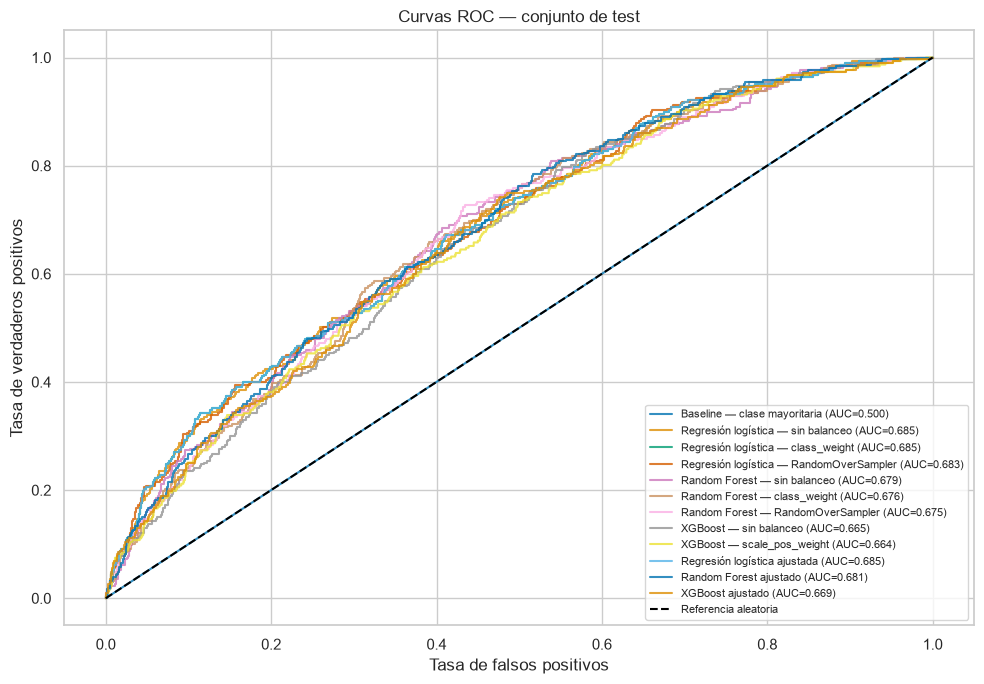

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
for name, result in evaluation.items():
    fpr, tpr, _ = roc_curve(y_test, result["probabilities"])
    auc_value = result["metrics"]["ROC_AUC"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})", alpha=0.8)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Referencia aleatoria")
ax.set(
    title="Curvas ROC — conjunto de test",
    xlabel="Tasa de falsos positivos",
    ylabel="Tasa de verdaderos positivos",
)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 17. Curvas Precision-Recall

Las curvas precision-recall muestran cómo varía la precisión de las alertas cuando se revisan más casos de mayor riesgo. Para este caso de uso, PR-AUC es especialmente relevante porque el sistema está orientado a priorizar préstamos para revisión y, por tanto, a ordenar correctamente los casos positivos antes de decidir el umbral operativo.

PR-AUC no determina por sí sola el mejor modelo, porque la capacidad del analista y la tolerancia a falsos positivos también importan. Se usa como medida de calidad del ranking y como complemento útil al recall y a la especificidad.


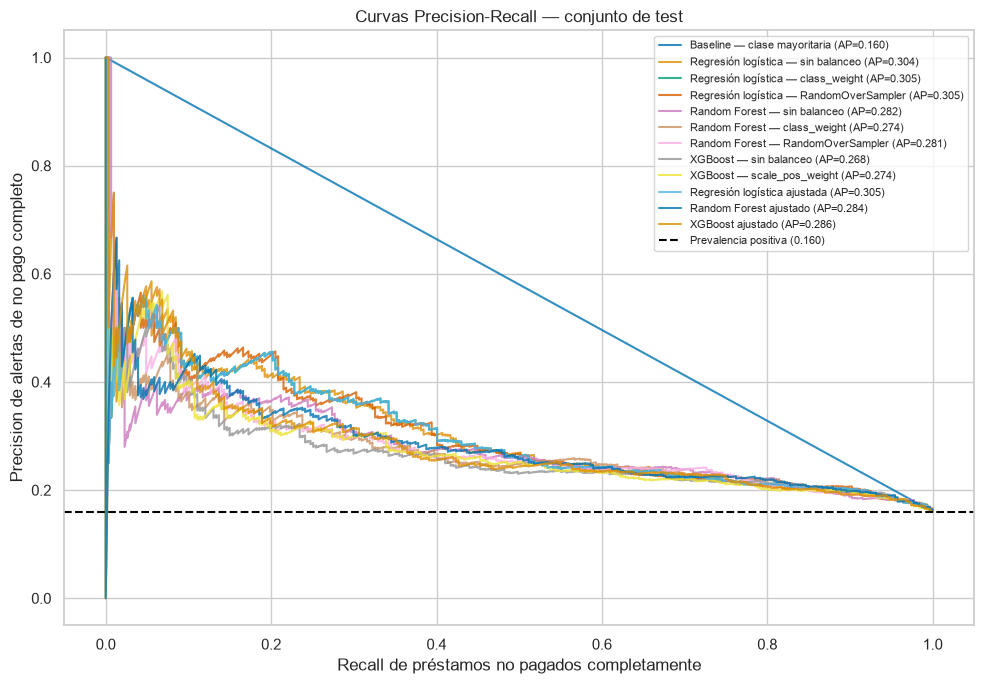

In [15]:
positive_prevalence = float(y_test.mean())
fig, ax = plt.subplots(figsize=(10, 7))
for name, result in evaluation.items():
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, result["probabilities"]
    )
    ap = result["metrics"]["PR_AUC"]
    ax.plot(
        recall_curve,
        precision_curve,
        label=f"{name} (AP={ap:.3f})",
        alpha=0.8,
    )
ax.axhline(
    positive_prevalence,
    linestyle="--",
    color="black",
    label=f"Prevalencia positiva ({positive_prevalence:.3f})",
)
ax.set(
    title="Curvas Precision-Recall — conjunto de test",
    xlabel="Recall de préstamos no pagados completamente",
    ylabel="Precision de alertas de no pago completo",
)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## 18. Matrices de confusión

En cada matriz, **TN** son préstamos pagados correctamente reconocidos, **FP** son préstamos pagados que se alertarían erróneamente, **FN** son préstamos no pagados que el modelo no detecta y **TP** son préstamos no pagados detectados. Un FN puede representar riesgo no identificado; un FP puede generar revisión innecesaria o rechazo injustificado. El coste relativo depende del proceso y no se puede inferir sin información económica adicional.

,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos
Modelo,,,,
Baseline — clase mayoritaria,1609,0,307,0
Regresión logística — sin balanceo,1598,11,295,12
Regresión logística — class_weight,1057,552,130,177
Regresión logística — RandomOverSampler,1077,532,135,172
Random Forest — sin balanceo,1607,2,304,3
Random Forest — class_weight,1364,245,209,98
Random Forest — RandomOverSampler,1524,85,261,46
XGBoost — sin balanceo,1601,8,300,7
XGBoost — scale_pos_weight,1143,466,152,155


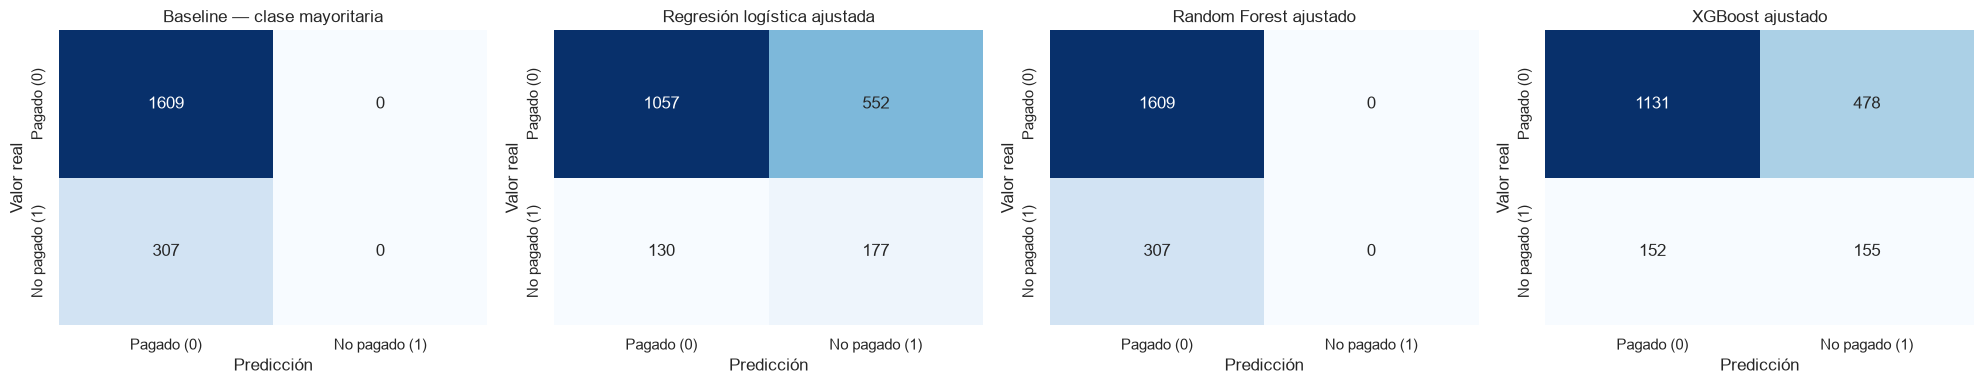

In [16]:
display(
    confusion_summary.rename(
        columns={
            "TN": "Verdaderos negativos",
            "FP": "Falsos positivos",
            "FN": "Falsos negativos",
            "TP": "Verdaderos positivos",
        }
    )
)

primary_names = [
    "Baseline — clase mayoritaria",
    "Regresión logística ajustada",
    "Random Forest ajustado",
    "XGBoost ajustado",
]
matrix_names = [name for name in primary_names if name in evaluation]
fig, axes = plt.subplots(
    1, len(matrix_names), figsize=(5 * len(matrix_names), 4)
)
if len(matrix_names) == 1:
    axes = [axes]
for ax, name in zip(axes, matrix_names):
    sns.heatmap(
        evaluation[name]["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pagado (0)", "No pagado (1)"],
        yticklabels=["Pagado (0)", "No pagado (1)"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

## 19. Probabilidades estimadas de no pago completo

Para los modelos con `predict_proba`, la columna de clase 1 representa la **probabilidad estimada de no pago completo**. No se denomina Probability of Default regulatoria. Las probabilidades son estimaciones del modelo, sujetas a los datos históricos y a su calibración.

In [17]:
probability_model_name = "XGBoost ajustado"
probabilities_for_examples = evaluation[probability_model_name]["probabilities"]
predictions_for_examples = evaluation[probability_model_name]["predictions"]
example_rows = X_test.head(10).copy()
example_rows["Resultado real"] = y_test.loc[example_rows.index].map(
    {0: "Pagado completamente", 1: "No pagado completamente"}
)
example_rows["Predicción (umbral 0,50)"] = pd.Series(
    predictions_for_examples,
    index=X_test.index,
).loc[example_rows.index].map(
    {0: "Pagado completamente", 1: "No pagado completamente"}
)
example_rows["Probabilidad estimada de no pago completo"] = pd.Series(
    probabilities_for_examples,
    index=X_test.index,
).loc[example_rows.index]
display(example_rows)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,Resultado real,"Predicción (umbral 0,50)",Probabilidad estimada de no pago completo
8157,0,debt_consolidation,0.1551,418.9900,11.0349,15.3800,647,"1,860.0000",11214,70.1000,0,0,0,Pagado completamente,No pagado completamente,0.5354
1928,1,debt_consolidation,0.0800,58.7600,10.8198,19.0600,732,"4,773.0000",27835,45.8000,0,0,0,Pagado completamente,Pagado completamente,0.2186
2779,1,all_other,0.1379,681.5100,11.8422,7.1200,712,"5,100.0000",7629,25.3000,0,0,0,Pagado completamente,Pagado completamente,0.3654
2520,1,all_other,0.1284,64.7200,9.6158,10.4800,702,"2,321.9583",653,3.7000,1,0,0,Pagado completamente,No pagado completamente,0.5582
2601,1,home_improvement,0.1568,350.0200,10.9508,7.6200,682,"2,850.0000",1815,34.2000,2,0,0,No pagado completamente,Pagado completamente,0.4952
9184,0,credit_card,0.1600,878.9400,12.4090,17.9300,692,"5,609.9583",181638,70.7000,6,0,0,Pagado completamente,No pagado completamente,0.7412
8884,0,debt_consolidation,0.1505,329.5700,10.9630,12.3100,707,"10,140.0000",25506,98.9000,4,0,0,Pagado completamente,No pagado completamente,0.6519
7696,1,major_purchase,0.1385,341.0400,11.3383,1.8000,722,"1,140.0000",3109,15.9000,2,0,0,No pagado completamente,Pagado completamente,0.3288
8067,0,educational,0.0933,31.9600,9.8782,0.9200,692,360.0000,362,25.9000,0,0,0,Pagado completamente,Pagado completamente,0.4738
809,1,all_other,0.1292,807.7400,11.4616,7.0600,687,"6,360.0000",9201,49.7000,2,1,1,Pagado completamente,No pagado completamente,0.5846


## 20. Calibración

Un modelo está bien calibrado cuando, entre los casos a los que asigna una probabilidad similar, la frecuencia observada de la clase positiva se aproxima a esa probabilidad. Se compara Brier Score y se representa una curva de fiabilidad. El calibrador se ajusta con validación cruzada únicamente en entrenamiento; el test se usa solo para evaluar las probabilidades finales.

,Modelo,Brier Score
1,Regresión logística — sin balanceo,0.1258
12,Regresión logística ajustada — calibrado,0.1259
10,Random Forest ajustado,0.1270
4,Random Forest — sin balanceo,0.1273
7,XGBoost — sin balanceo,0.1289
6,Random Forest — RandomOverSampler,0.1436
0,Baseline — clase mayoritaria,0.1602
5,Random Forest — class_weight,0.1684
8,XGBoost — scale_pos_weight,0.2067
11,XGBoost ajustado,0.2100


,Model,Balancing,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC,Brier_Score
0,Regresión logística ajustada — calibrado,Calibración CV en entrenamiento,0.8398,0.5000,0.0326,0.9938,0.0612,0.6852,0.3048,0.1259
1,Regresión logística ajustada,Según búsqueda CV,0.6441,0.2428,0.5765,0.6569,0.3417,0.6852,0.3048,0.2199
2,Regresión logística — class_weight,Pesos de clase,0.6441,0.2428,0.5765,0.6569,0.3417,0.6852,0.3048,0.2199
3,Regresión logística — RandomOverSampler,RandomOverSampler,0.6519,0.2443,0.5603,0.6694,0.3403,0.6829,0.3045,0.2188
4,Regresión logística — sin balanceo,Sin balanceo,0.8403,0.5217,0.0391,0.9932,0.0727,0.6846,0.3042,0.1258
5,XGBoost ajustado,Según búsqueda CV,0.6712,0.2449,0.5049,0.7029,0.3298,0.6693,0.2860,0.2100
6,Random Forest ajustado,Según búsqueda CV,0.8398,0.0000,0.0000,1.0000,0.0000,0.6806,0.2844,0.1270
7,Random Forest — sin balanceo,Sin balanceo,0.8403,0.6000,0.0098,0.9988,0.0192,0.6790,0.2824,0.1273
8,Random Forest — RandomOverSampler,RandomOverSampler,0.8194,0.3511,0.1498,0.9472,0.2100,0.6747,0.2810,0.1436
9,Random Forest — class_weight,Pesos de clase,0.7630,0.2857,0.3192,0.8477,0.3015,0.6764,0.2737,0.1684


,TN,FP,FN,TP
Modelo,,,,
Baseline — clase mayoritaria,1609,0,307,0
Regresión logística — sin balanceo,1598,11,295,12
Regresión logística — class_weight,1057,552,130,177
Regresión logística — RandomOverSampler,1077,532,135,172
Random Forest — sin balanceo,1607,2,304,3
Random Forest — class_weight,1364,245,209,98
Random Forest — RandomOverSampler,1524,85,261,46
XGBoost — sin balanceo,1601,8,300,7
XGBoost — scale_pos_weight,1143,466,152,155


,Modelo,Clase,precision,recall,f1-score,support
0,Baseline — clase mayoritaria,Pagado completamente,0.8398,1.0000,0.9129,"1,609.0000"
1,Baseline — clase mayoritaria,No pagado completamente,0.0000,0.0000,0.0000,307.0000
2,Baseline — clase mayoritaria,macro avg,0.4199,0.5000,0.4565,"1,916.0000"
3,Baseline — clase mayoritaria,weighted avg,0.7052,0.8398,0.7666,"1,916.0000"
4,Regresión logística — sin balanceo,Pagado completamente,0.8442,0.9932,0.9126,"1,609.0000"
5,Regresión logística — sin balanceo,No pagado completamente,0.5217,0.0391,0.0727,307.0000
6,Regresión logística — sin balanceo,macro avg,0.6830,0.5161,0.4927,"1,916.0000"
7,Regresión logística — sin balanceo,weighted avg,0.7925,0.8403,0.7780,"1,916.0000"
8,Regresión logística — class_weight,Pagado completamente,0.8905,0.6569,0.7561,"1,609.0000"
9,Regresión logística — class_weight,No pagado completamente,0.2428,0.5765,0.3417,307.0000


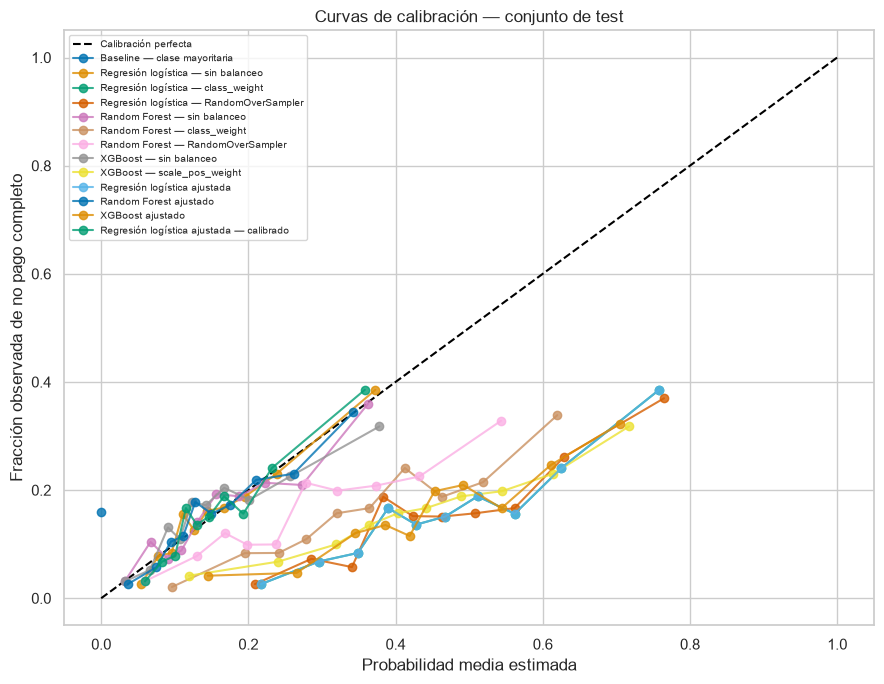

In [18]:
best_search_name = max(
    searches,
    key=lambda name: searches[name].best_score_,
)
best_cv_estimator = searches[best_search_name].best_estimator_
calibrated_model_name = f"{best_search_name} — calibrado"
calibrated_estimator = CalibratedClassifierCV(
    estimator=best_cv_estimator,
    method="sigmoid",
    cv=cv,
    n_jobs=1,
)
calibrated_estimator.fit(X_train, y_train)
calibrated_details = {
    "estimator": calibrated_estimator,
    "family": "Calibración",
    "balancing": "Calibración CV en entrenamiento",
    "cv_average_precision": searches[best_search_name].best_score_,
}
calibrated_evaluation = evaluate_estimator(
    calibrated_estimator, X_test, y_test
)
models[calibrated_model_name] = calibrated_details
evaluation[calibrated_model_name] = {
    "predictions": calibrated_evaluation[0],
    "probabilities": calibrated_evaluation[1],
    "metrics": calibrated_evaluation[2],
    "report": calibrated_evaluation[3],
    "confusion_matrix": calibrated_evaluation[4],
}
calibrated_metrics = calibrated_evaluation[2]
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            [
                {
                    "Model": calibrated_model_name,
                    "Balancing": calibrated_details["balancing"],
                    **calibrated_metrics,
                }
            ]
        ),
    ],
    ignore_index=True,
).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
classification_reports = pd.concat(
    [
        classification_reports,
        pd.DataFrame(
            [
                {"Modelo": calibrated_model_name, "Clase": label, **values}
                for label, values in calibrated_evaluation[3].items()
                if isinstance(values, dict)
            ]
        ),
    ],
    ignore_index=True,
)
tn, fp, fn, tp = calibrated_evaluation[4].ravel()
confusion_summary.loc[calibrated_model_name, ["TN", "FP", "FN", "TP"]] = [
    tn,
    fp,
    fn,
    tp,
]
confusion_summary = confusion_summary.astype(int)

calibration_rows = []
for name, result in evaluation.items():
    fraction_positive, mean_predicted = calibration_curve(
        y_test,
        result["probabilities"],
        n_bins=10,
        strategy="quantile",
    )
    calibration_rows.append(
        {
            "Modelo": name,
            "Brier Score": result["metrics"]["Brier_Score"],
            "Fracción positiva por intervalo": fraction_positive,
            "Probabilidad media por intervalo": mean_predicted,
        }
    )
calibration_summary = pd.DataFrame(
    [
        {"Modelo": name, "Brier Score": result["metrics"]["Brier_Score"]}
        for name, result in evaluation.items()
    ]
).sort_values("Brier Score")
display(calibration_summary)
display(results_df.round(4))
display(confusion_summary)
display(classification_reports)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Calibración perfecta")
for row in calibration_rows:
    ax.plot(
        row["Probabilidad media por intervalo"],
        row["Fracción positiva por intervalo"],
        marker="o",
        label=row["Modelo"],
        alpha=0.8,
    )
ax.set(
    title="Curvas de calibración — conjunto de test",
    xlabel="Probabilidad media estimada",
    ylabel="Fracción observada de no pago completo",
)
ax.legend(loc="best", fontsize=7)
plt.tight_layout()
plt.show()

## 21. Interpretabilidad

Se muestran coeficientes de la regresión logística ajustada y las importancias nativas de modelos de árboles. Para XGBoost se utiliza SHAP sobre una muestra de entrenamiento y se representa una explicación global y otra local. El explicador de árboles descompone la salida interna del modelo (margen, no probabilidad calibrada). Estas medidas describen contribuciones predictivas bajo el modelo; **no implican causalidad**, ni demuestran que una variable produzca el resultado.

,Variable transformada,Coeficiente,Magnitud absoluta
18,categoricas__purpose_small_business,0.6040,0.6040
13,categoricas__purpose_credit_card,-0.4556,0.4556
17,categoricas__purpose_major_purchase,-0.3099,0.3099
14,categoricas__purpose_debt_consolidation,-0.3094,0.3094
3,numericas__log.annual.inc,-0.2839,0.2839
5,numericas__fico,-0.2449,0.2449
2,numericas__installment,0.2408,0.2408
16,categoricas__purpose_home_improvement,0.2216,0.2216
9,numericas__inq.last.6mths,0.2090,0.2090
7,numericas__revol.bal,0.1566,0.1566


Random Forest ajustado


,Variable transformada,Importancia
1,numericas__int.rate,0.1131
2,numericas__installment,0.1115
3,numericas__log.annual.inc,0.1113
7,numericas__revol.bal,0.1055
8,numericas__revol.util,0.1026
4,numericas__dti,0.0956
6,numericas__days.with.cr.line,0.0956
5,numericas__fico,0.0838
9,numericas__inq.last.6mths,0.0699
0,numericas__credit.policy,0.0374


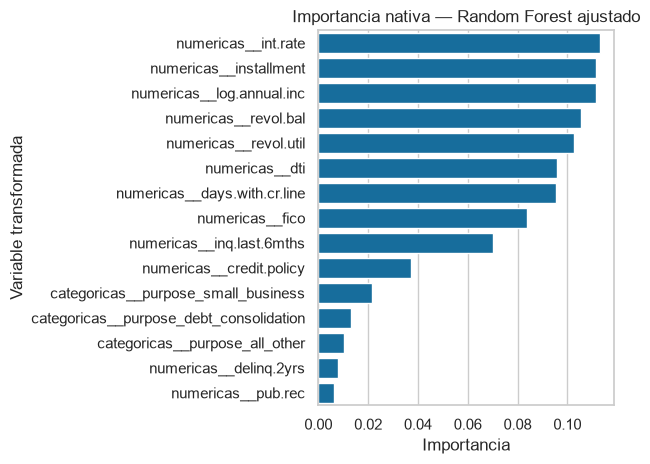

XGBoost ajustado


,Variable transformada,Importancia
0,numericas__credit.policy,0.1831
1,numericas__int.rate,0.0940
18,categoricas__purpose_small_business,0.0804
9,numericas__inq.last.6mths,0.0791
10,numericas__delinq.2yrs,0.0447
8,numericas__revol.util,0.0442
13,categoricas__purpose_credit_card,0.0441
3,numericas__log.annual.inc,0.0426
5,numericas__fico,0.0420
7,numericas__revol.bal,0.0405


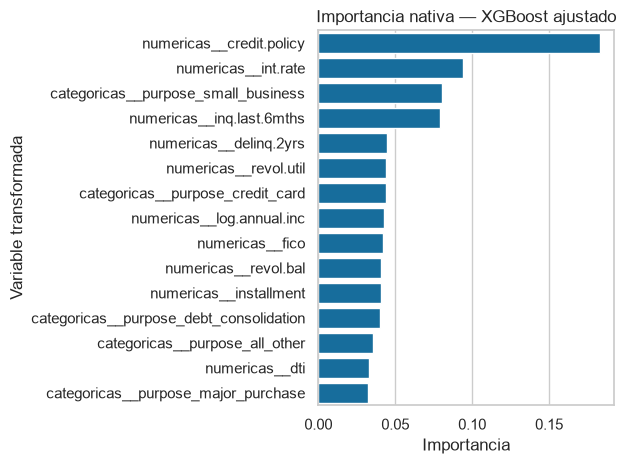

,Variable transformada,Importancia media absoluta SHAP
3,numericas__log.annual.inc,0.2126
1,numericas__int.rate,0.2013
9,numericas__inq.last.6mths,0.1767
2,numericas__installment,0.1338
0,numericas__credit.policy,0.1257
8,numericas__revol.util,0.0996
7,numericas__revol.bal,0.0983
5,numericas__fico,0.0919
6,numericas__days.with.cr.line,0.0682
18,categoricas__purpose_small_business,0.0649


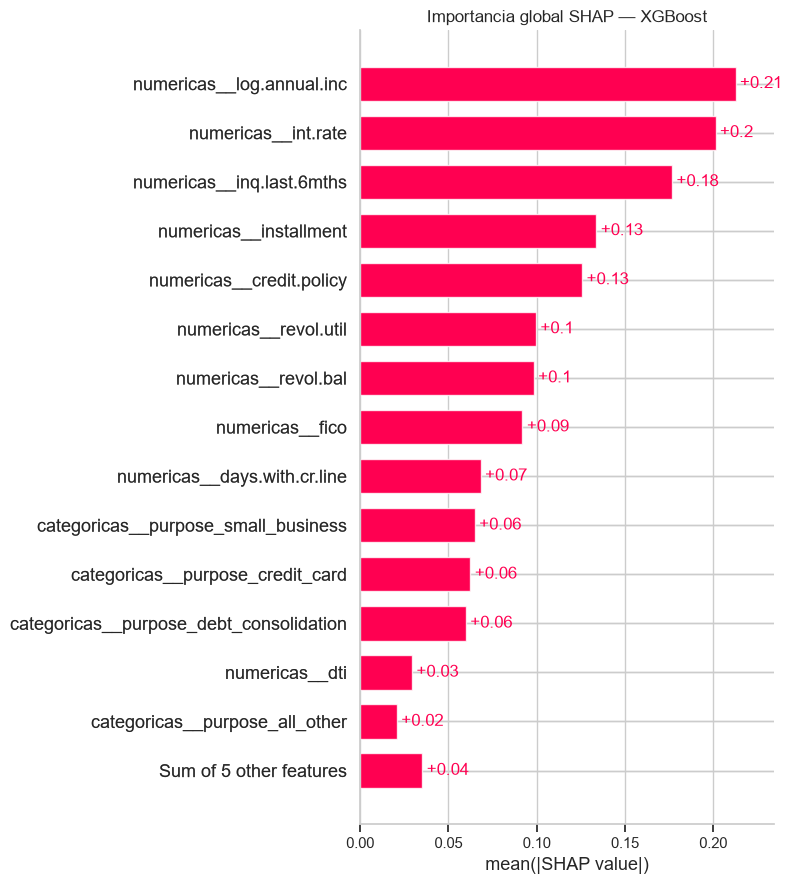

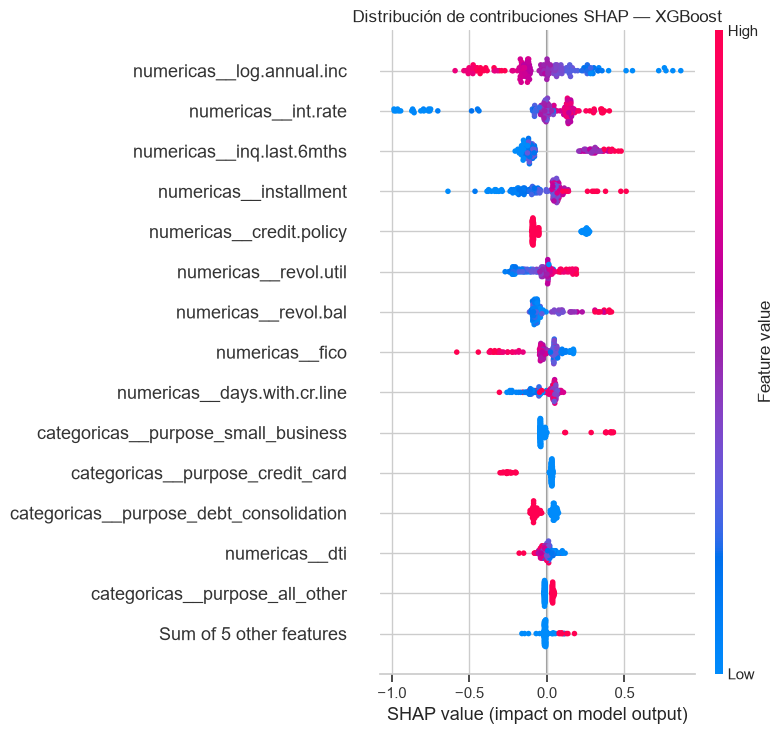

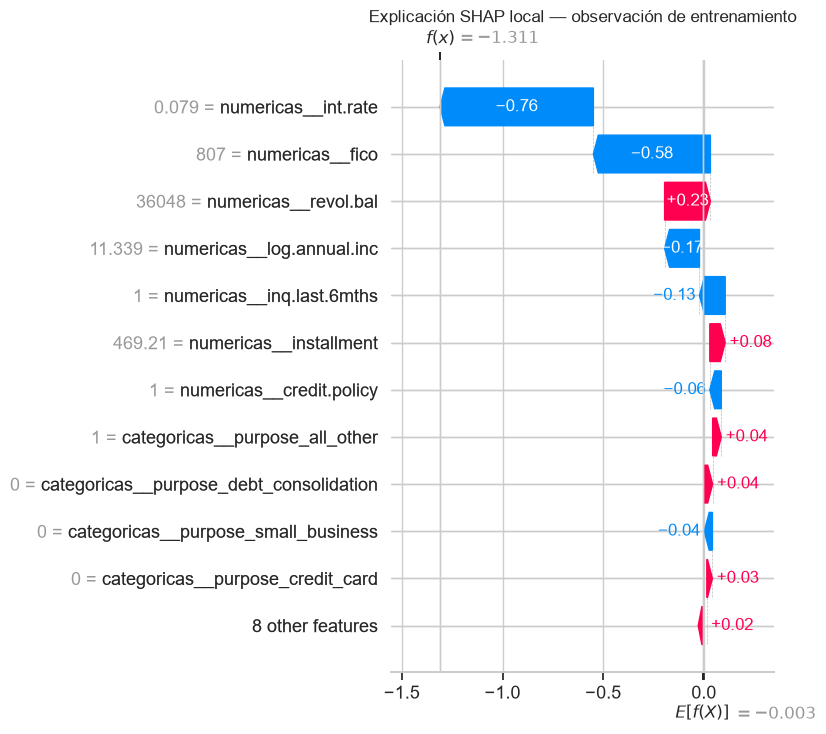

In [19]:
feature_names = (
    models["Regresión logística ajustada"]["estimator"]
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)
logistic_estimator = models[
    "Regresión logística ajustada"
]["estimator"].named_steps["modelo"]
logistic_coefficients = pd.DataFrame(
    {
        "Variable transformada": feature_names,
        "Coeficiente": logistic_estimator.coef_[0],
    }
)
logistic_coefficients["Magnitud absoluta"] = (
    logistic_coefficients["Coeficiente"].abs()
)
display(
    logistic_coefficients.sort_values(
        "Magnitud absoluta", ascending=False
    ).head(15)
)

for model_name in ["Random Forest ajustado", "XGBoost ajustado"]:
    pipeline = models[model_name]["estimator"]
    tree_model = pipeline.named_steps["modelo"]
    importances = pd.DataFrame(
        {
            "Variable transformada": feature_names,
            "Importancia": tree_model.feature_importances_,
        }
    ).sort_values("Importancia", ascending=False)
    print(model_name)
    display(importances.head(15))
    sns.barplot(
        data=importances.head(15),
        x="Importancia",
        y="Variable transformada",
    )
    plt.title(f"Importancia nativa — {model_name}")
    plt.tight_layout()
    plt.show()

xgb_pipeline = models["XGBoost ajustado"]["estimator"]
xgb_preprocessor = xgb_pipeline.named_steps["preprocesamiento"]
xgb_model = xgb_pipeline.named_steps["modelo"]
background_raw = X_train.sample(
    n=min(100, len(X_train)),
    random_state=SEED,
)
explanation_raw = X_train.sample(
    n=min(150, len(X_train)),
    random_state=SEED + 1,
)
explanation_data = xgb_preprocessor.transform(explanation_raw)
explainer = shap.TreeExplainer(
    xgb_model,
    feature_perturbation="tree_path_dependent",
)
shap_values = explainer(explanation_data)
if shap_values.values.ndim == 3:
    positive_values = shap_values.values[:, :, 1]
    positive_base_values = shap_values.base_values[:, 1]
else:
    positive_values = shap_values.values
    positive_base_values = shap_values.base_values
shap_explanation = shap.Explanation(
    values=positive_values,
    base_values=positive_base_values,
    data=explanation_data,
    feature_names=feature_names,
)
shap_importance = pd.DataFrame(
    {
        "Variable transformada": feature_names,
        "Importancia media absoluta SHAP": np.abs(positive_values).mean(axis=0),
    }
).sort_values("Importancia media absoluta SHAP", ascending=False)
display(shap_importance.head(15))
shap.plots.bar(shap_explanation, max_display=15, show=False)
plt.title("Importancia global SHAP — XGBoost")
plt.tight_layout()
plt.show()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("Distribución de contribuciones SHAP — XGBoost")
plt.tight_layout()
plt.show()
shap.plots.waterfall(shap_explanation[0], max_display=12, show=False)
plt.title("Explicación SHAP local — observación de entrenamiento")
plt.tight_layout()
plt.show()

## 22. Análisis de errores

Los errores se examinan para el modelo ajustado cuya PR-AUC media de validación cruzada fue mayor entre las búsquedas. Esta elección se hizo exclusivamente con entrenamiento. Los falsos negativos son especialmente relevantes para el objetivo de detección; los falsos positivos son alertas de riesgo que no correspondían a positivos reales. El análisis describe estos registros del test, sin inferir causas.

In [20]:
selected_search = searches[best_search_name]
selected_test_predictions = evaluation[best_search_name]["predictions"]
error_table = X_test.copy()
error_table["Resultado real"] = y_test
error_table["Predicción"] = selected_test_predictions
error_table["Tipo de resultado"] = np.select(
    [
        (error_table["Resultado real"] == 1)
        & (error_table["Predicción"] == 0),
        (error_table["Resultado real"] == 0)
        & (error_table["Predicción"] == 1),
    ],
    ["Falso negativo", "Falso positivo"],
    default="Acierto",
)

false_negatives = error_table.loc[
    error_table["Tipo de resultado"] == "Falso negativo"
]
false_positives = error_table.loc[
    error_table["Tipo de resultado"] == "Falso positivo"
]
print(f"Modelo para el análisis de errores: {best_search_name}")
print(f"Falsos negativos: {len(false_negatives)}")
print(f"Falsos positivos: {len(false_positives)}")
display(false_negatives.head(10))
display(false_positives.head(10))

error_profile_rows = []
for error_name, error_data in [
    ("Falsos negativos", false_negatives),
    ("Falsos positivos", false_positives),
    ("Verdaderos positivos", error_table.loc[
        (error_table["Resultado real"] == 1)
        & (error_table["Predicción"] == 1)
    ]),
    ("Verdaderos negativos", error_table.loc[
        (error_table["Resultado real"] == 0)
        & (error_table["Predicción"] == 0)
    ]),
]:
    row = {"Tipo de resultado": error_name, "Casos": len(error_data)}
    for column in ["fico", "int.rate", "dti", "revol.util"]:
        if column in error_data:
            row[f"Mediana: {column}"] = error_data[column].median()
    error_profile_rows.append(row)
display(pd.DataFrame(error_profile_rows).set_index("Tipo de resultado"))

Modelo para el análisis de errores: Regresión logística ajustada
Falsos negativos: 130
Falsos positivos: 552


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,Resultado real,Predicción,Tipo de resultado
7696,1,major_purchase,0.1385,341.0400,11.3383,1.8000,722,"1,140.0000",3109,15.9000,2,0,0,1,0,Falso negativo
7692,1,all_other,0.1496,277.1600,11.0413,4.5000,712,"1,379.9583",5009,49.6000,0,0,0,1,0,Falso negativo
3566,1,credit_card,0.1505,402.4200,11.7998,16.7900,682,"11,190.0000",54194,85.7000,0,0,1,1,0,Falso negativo
3225,1,all_other,0.1126,315.4900,10.5965,23.5200,717,"3,359.9583",8405,42.6000,2,0,0,1,0,Falso negativo
918,1,debt_consolidation,0.1166,170.2200,10.4711,17.6900,702,"3,930.0000",12110,30.2000,2,1,0,1,0,Falso negativo
6500,1,all_other,0.0705,148.3200,10.6874,7.3700,772,"3,780.0417",0,0.0000,4,0,0,1,0,Falso negativo
7709,1,major_purchase,0.1287,840.8300,11.4595,0.1300,757,"2,190.0000",14,0.2000,2,0,0,1,0,Falso negativo
6966,1,all_other,0.1218,699.3000,10.8889,4.8400,802,"8,010.0000",120,2.4000,1,0,0,1,0,Falso negativo
5057,1,credit_card,0.1287,645.7600,11.2898,10.9300,742,"2,610.0000",222,2.8000,0,1,0,1,0,Falso negativo
4957,1,debt_consolidation,0.1287,815.6100,11.8130,8.0800,717,"3,839.9583",26361,73.2000,1,0,0,1,0,Falso negativo


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,Resultado real,Predicción,Tipo de resultado
8157,0,debt_consolidation,0.1551,418.9900,11.0349,15.3800,647,"1,860.0000",11214,70.1000,0,0,0,0,1,Falso positivo
2520,1,all_other,0.1284,64.7200,9.6158,10.4800,702,"2,321.9583",653,3.7000,1,0,0,0,1,Falso positivo
9184,0,credit_card,0.1600,878.9400,12.4090,17.9300,692,"5,609.9583",181638,70.7000,6,0,0,0,1,Falso positivo
8884,0,debt_consolidation,0.1505,329.5700,10.9630,12.3100,707,"10,140.0000",25506,98.9000,4,0,0,0,1,Falso positivo
8067,0,educational,0.0933,31.9600,9.8782,0.9200,692,360.0000,362,25.9000,0,0,0,0,1,Falso positivo
809,1,all_other,0.1292,807.7400,11.4616,7.0600,687,"6,360.0000",9201,49.7000,2,1,1,0,1,Falso positivo
4968,1,all_other,0.1322,101.4100,10.4913,22.4300,677,"5,369.9583",12905,81.2000,1,0,1,0,1,Falso positivo
7761,0,credit_card,0.1280,67.2000,9.2103,3.4800,647,"1,169.9583",571,61.9000,0,1,0,0,1,Falso positivo
7759,0,all_other,0.1312,180.5700,8.2940,15.0000,662,178.9583,0,47.8000,1,0,0,0,1,Falso positivo
9431,0,home_improvement,0.1148,32.9700,11.4065,20.5000,732,"4,590.0417",119702,19.1000,2,0,0,0,1,Falso positivo


,Casos,Mediana: fico,Mediana: int.rate,Mediana: dti,Mediana: revol.util
Tipo de resultado,,,,,
Falsos negativos,130,712.0000,0.1194,12.5150,37.1500
Falsos positivos,552,687.0000,0.1392,13.4850,61.3500
Verdaderos positivos,177,677.0000,0.1438,13.6000,59.3000
Verdaderos negativos,1057,727.0000,0.1114,12.2600,35.2000


## 23. Comparación de modelos

### Regresión logística

En test, las variantes con `class_weight` y RandomOverSampler detectan muchos más positivos con el umbral 0,50 (recall de 0,573 y 0,577) que la variante sin balanceo (0,046). La contrapartida es una reducción de precision (0,240 y 0,232 frente a 0,519) y más falsos positivos. La regresión logística ajustada por validación cruzada logra PR-AUC 0,302 en test, pero con el umbral predeterminado solo alcanza recall 0,046: la calidad de ordenación de probabilidades no implica un buen punto de corte.

### Random Forest

El Random Forest con pesos de clase presenta recall 0,326, frente a 0,007 sin balanceo y 0,065 con RandomOverSampler. El ajuste aleatorio seleccionado por CV también produce recall bajo (0,007) con el umbral 0,50. Sus resultados muestran que el tratamiento de clases y los hiperparámetros modifican notablemente las decisiones binarias, aunque las métricas de ranking cambian menos.

### XGBoost

La ponderación `scale_pos_weight` aumenta el recall a 0,528 frente a 0,033 sin ponderación y 0,036 en la búsqueda ajustada; precision disminuye a 0,251 desde 0,526 sin balanceo. La PR-AUC de las variantes de XGBoost se mantiene alrededor de 0,272–0,276 en test, por lo que el gran cambio de recall al umbral fijo no equivale a una mejora comparable de la ordenación.

### Efecto general del balanceo

En este experimento, pesos de clase, RandomOverSampler y `scale_pos_weight` elevan el recall de varios modelos y, a la vez, incrementan los falsos positivos y suelen empeorar Brier Score. El beneficio operativo depende del coste relativo de los errores y de un umbral elegido en validación, no disponible como dato de negocio aquí. Las métricas de esta sección describen el test reservado y no se han utilizado para reentrenar ni seleccionar hiperparámetros.

In [21]:
family_comparison = results_df.assign(
    Familia=results_df["Model"].map(
        {name: details["family"] for name, details in models.items()}
    )
)
family_summary = (
    family_comparison.groupby("Familia", as_index=False)[
        ["Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "Brier_Score"]
    ]
    .mean()
    .sort_values("PR_AUC", ascending=False)
)
display(family_summary)

for family in ["Regresión logística", "Random Forest", "XGBoost"]:
    family_rows = family_comparison.loc[
        family_comparison["Familia"] == family,
        ["Model", "Balancing", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "Brier_Score"],
    ]
    print(f"Comparación de configuraciones — {family}")
    display(family_rows.sort_values("PR_AUC", ascending=False))

,Familia,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
1,Calibración,0.5000,0.0326,0.0612,0.6852,0.3048,0.1259
3,Regresión logística,0.3129,0.4381,0.2741,0.6845,0.3046,0.1961
2,Random Forest,0.3092,0.1197,0.1327,0.6777,0.2804,0.1416
4,XGBoost,0.3204,0.3442,0.2358,0.6661,0.2758,0.1819
0,Baseline,0.0000,0.0000,0.0000,0.5000,0.1602,0.1602


Comparación de configuraciones — Regresión logística


,Model,Balancing,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
1,Regresión logística ajustada,Según búsqueda CV,0.2428,0.5765,0.3417,0.6852,0.3048,0.2199
2,Regresión logística — class_weight,Pesos de clase,0.2428,0.5765,0.3417,0.6852,0.3048,0.2199
3,Regresión logística — RandomOverSampler,RandomOverSampler,0.2443,0.5603,0.3403,0.6829,0.3045,0.2188
4,Regresión logística — sin balanceo,Sin balanceo,0.5217,0.0391,0.0727,0.6846,0.3042,0.1258


Comparación de configuraciones — Random Forest


,Model,Balancing,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
6,Random Forest ajustado,Según búsqueda CV,0.0000,0.0000,0.0000,0.6806,0.2844,0.1270
7,Random Forest — sin balanceo,Sin balanceo,0.6000,0.0098,0.0192,0.6790,0.2824,0.1273
8,Random Forest — RandomOverSampler,RandomOverSampler,0.3511,0.1498,0.2100,0.6747,0.2810,0.1436
9,Random Forest — class_weight,Pesos de clase,0.2857,0.3192,0.3015,0.6764,0.2737,0.1684


Comparación de configuraciones — XGBoost


,Model,Balancing,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
5,XGBoost ajustado,Según búsqueda CV,0.2449,0.5049,0.3298,0.6693,0.2860,0.2100
10,XGBoost — scale_pos_weight,Ponderación positiva,0.2496,0.5049,0.3341,0.6642,0.2736,0.2067
11,XGBoost — sin balanceo,Sin balanceo,0.4667,0.0228,0.0435,0.6647,0.2679,0.1289


## 24. Conclusiones

La comparación final se interpreta como apoyo a la revisión del analista, no como una decisión automática de concesión/rechazo de crédito. Los resultados de validación se usan para seleccionar el threshold operativo o para comparar escenarios de capacidad de revisión; el test solo sirve para confirmar dicho comportamiento en datos no vistos.

El mejor modelo para este caso de uso depende de la capacidad de revisión y del peso relativo que el analista quiera dar a la cobertura de impagos frente a los falsos positivos. En general:

- Regresión logística sin balanceo ofrece mejor specificity y Brier entre las configuraciones relevantes y suele aportar una base más estable para probabilidades interpretables.
- Regresión logística + RandomOverSampler suele mejorar el recall y la F2 de las configuraciones evaluadas, pero adopta un coste más alto en falsos positivos.
- Random Forest + `class_weight` logra un recall más alto que la regresión logística sin balanceo, mostrando una mejor captación de casos positivos pero con mayor volumen de revisión.
- XGBoost ajustado tiene un mejor PR-AUC y suele ofrecer un ranking de riesgo más fuerte, lo que lo convierte en una opción atractiva para priorizar alertas, aunque la elección final debe equilibrarse con la capacidad de revisión.

La comparación final de métricas, capacidades y thresholds debe leerse como un sistema de apoyo a la decisión humana y no como un mecanismo de auto-decisionamiento crediticio.


## 25. Limitaciones

- Los registros corresponden a LendingClub de 2007–2010; los criterios de crédito, el comportamiento de los prestatarios y el entorno económico pueden haber cambiado.
- La representatividad respecto a otras entidades, épocas o solicitudes actuales no está establecida.
- `not.fully.paid` es la definición de resultado disponible en el conjunto; no equivale necesariamente a una definición regulatoria de incumplimiento ni a una pérdida económica.
- El CSV no aporta una variable temporal de originación utilizable aquí para una partición cronológica; por eso la evaluación es estratificada y no sustituye una validación temporal.
- Pueden faltar variables que un sistema real conocería al momento de la decisión, y `credit.policy` puede reflejar reglas de suscripción históricas.
- No se dispone de costes reales de falsos positivos/falsos negativos, recuperación, exposición o pérdida, por lo que no es posible optimizar un umbral económico.
- El ejercicio académico no cubre gobernanza, explicabilidad regulatoria, equidad, monitorización, cambios de distribución ni validación externa necesarios para producción.
- Este modelo no toma decisiones de concesión/rechazo; actúa como sistema de apoyo para priorizar casos para revisión por un analista de riesgo. La decisión final siempre debe ser humana.


## 26. Reproducibilidad

Las semillas aleatorias se fijan en 42 para la partición, la validación cruzada, los modelos y RandomOverSampler. La tabla siguiente registra las versiones del entorno que ejecuta el notebook.

In [22]:
package_versions = {}
for package_name in [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "imbalanced-learn",
    "xgboost",
    "shap",
]:
    package_versions[package_name] = importlib.metadata.version(package_name)

reproducibility = pd.DataFrame(
    [
        {"Componente": "Python", "Versión": platform.python_version()},
        *[
            {"Componente": package, "Versión": version}
            for package, version in package_versions.items()
        ],
        {"Componente": "Semilla aleatoria", "Versión": str(SEED)},
        {"Componente": "Partición de test", "Versión": f"{TEST_SIZE:.0%} estratificada"},
    ]
)
display(reproducibility)

,Componente,Versión
0,Python,3.14.2
1,numpy,2.5.3
2,pandas,3.0.6
3,scipy,1.18.1
4,scikit-learn,1.9.1
5,imbalanced-learn,0.14.2
6,xgboost,3.4.1
7,shap,0.52.0
8,Semilla aleatoria,42
9,Partición de test,20% estratificada


## 27. Matrices de confusión a umbral 0,50

Se muestran las matrices de confusión para todos los modelos entrenados y evaluados sobre el conjunto de prueba. Las filas representan la clase real y las columnas la predicción del modelo.

En cada caso, la diagonal principal indica los aciertos, mientras que los elementos fuera de ella corresponden a falsos positivos y falsos negativos.

,Modelo,Balancing,TN,FP,FN,TP
0,Baseline — clase mayoritaria,Sin balanceo,1609,0,307,0
10,Random Forest ajustado,Según búsqueda CV,1609,0,307,0
6,Random Forest — RandomOverSampler,RandomOverSampler,1524,85,261,46
5,Random Forest — class_weight,Pesos de clase,1364,245,209,98
4,Random Forest — sin balanceo,Sin balanceo,1607,2,304,3
9,Regresión logística ajustada,Según búsqueda CV,1057,552,130,177
12,Regresión logística ajustada — calibrado,Calibración CV en entrenamiento,1599,10,297,10
3,Regresión logística — RandomOverSampler,RandomOverSampler,1077,532,135,172
2,Regresión logística — class_weight,Pesos de clase,1057,552,130,177
1,Regresión logística — sin balanceo,Sin balanceo,1598,11,295,12


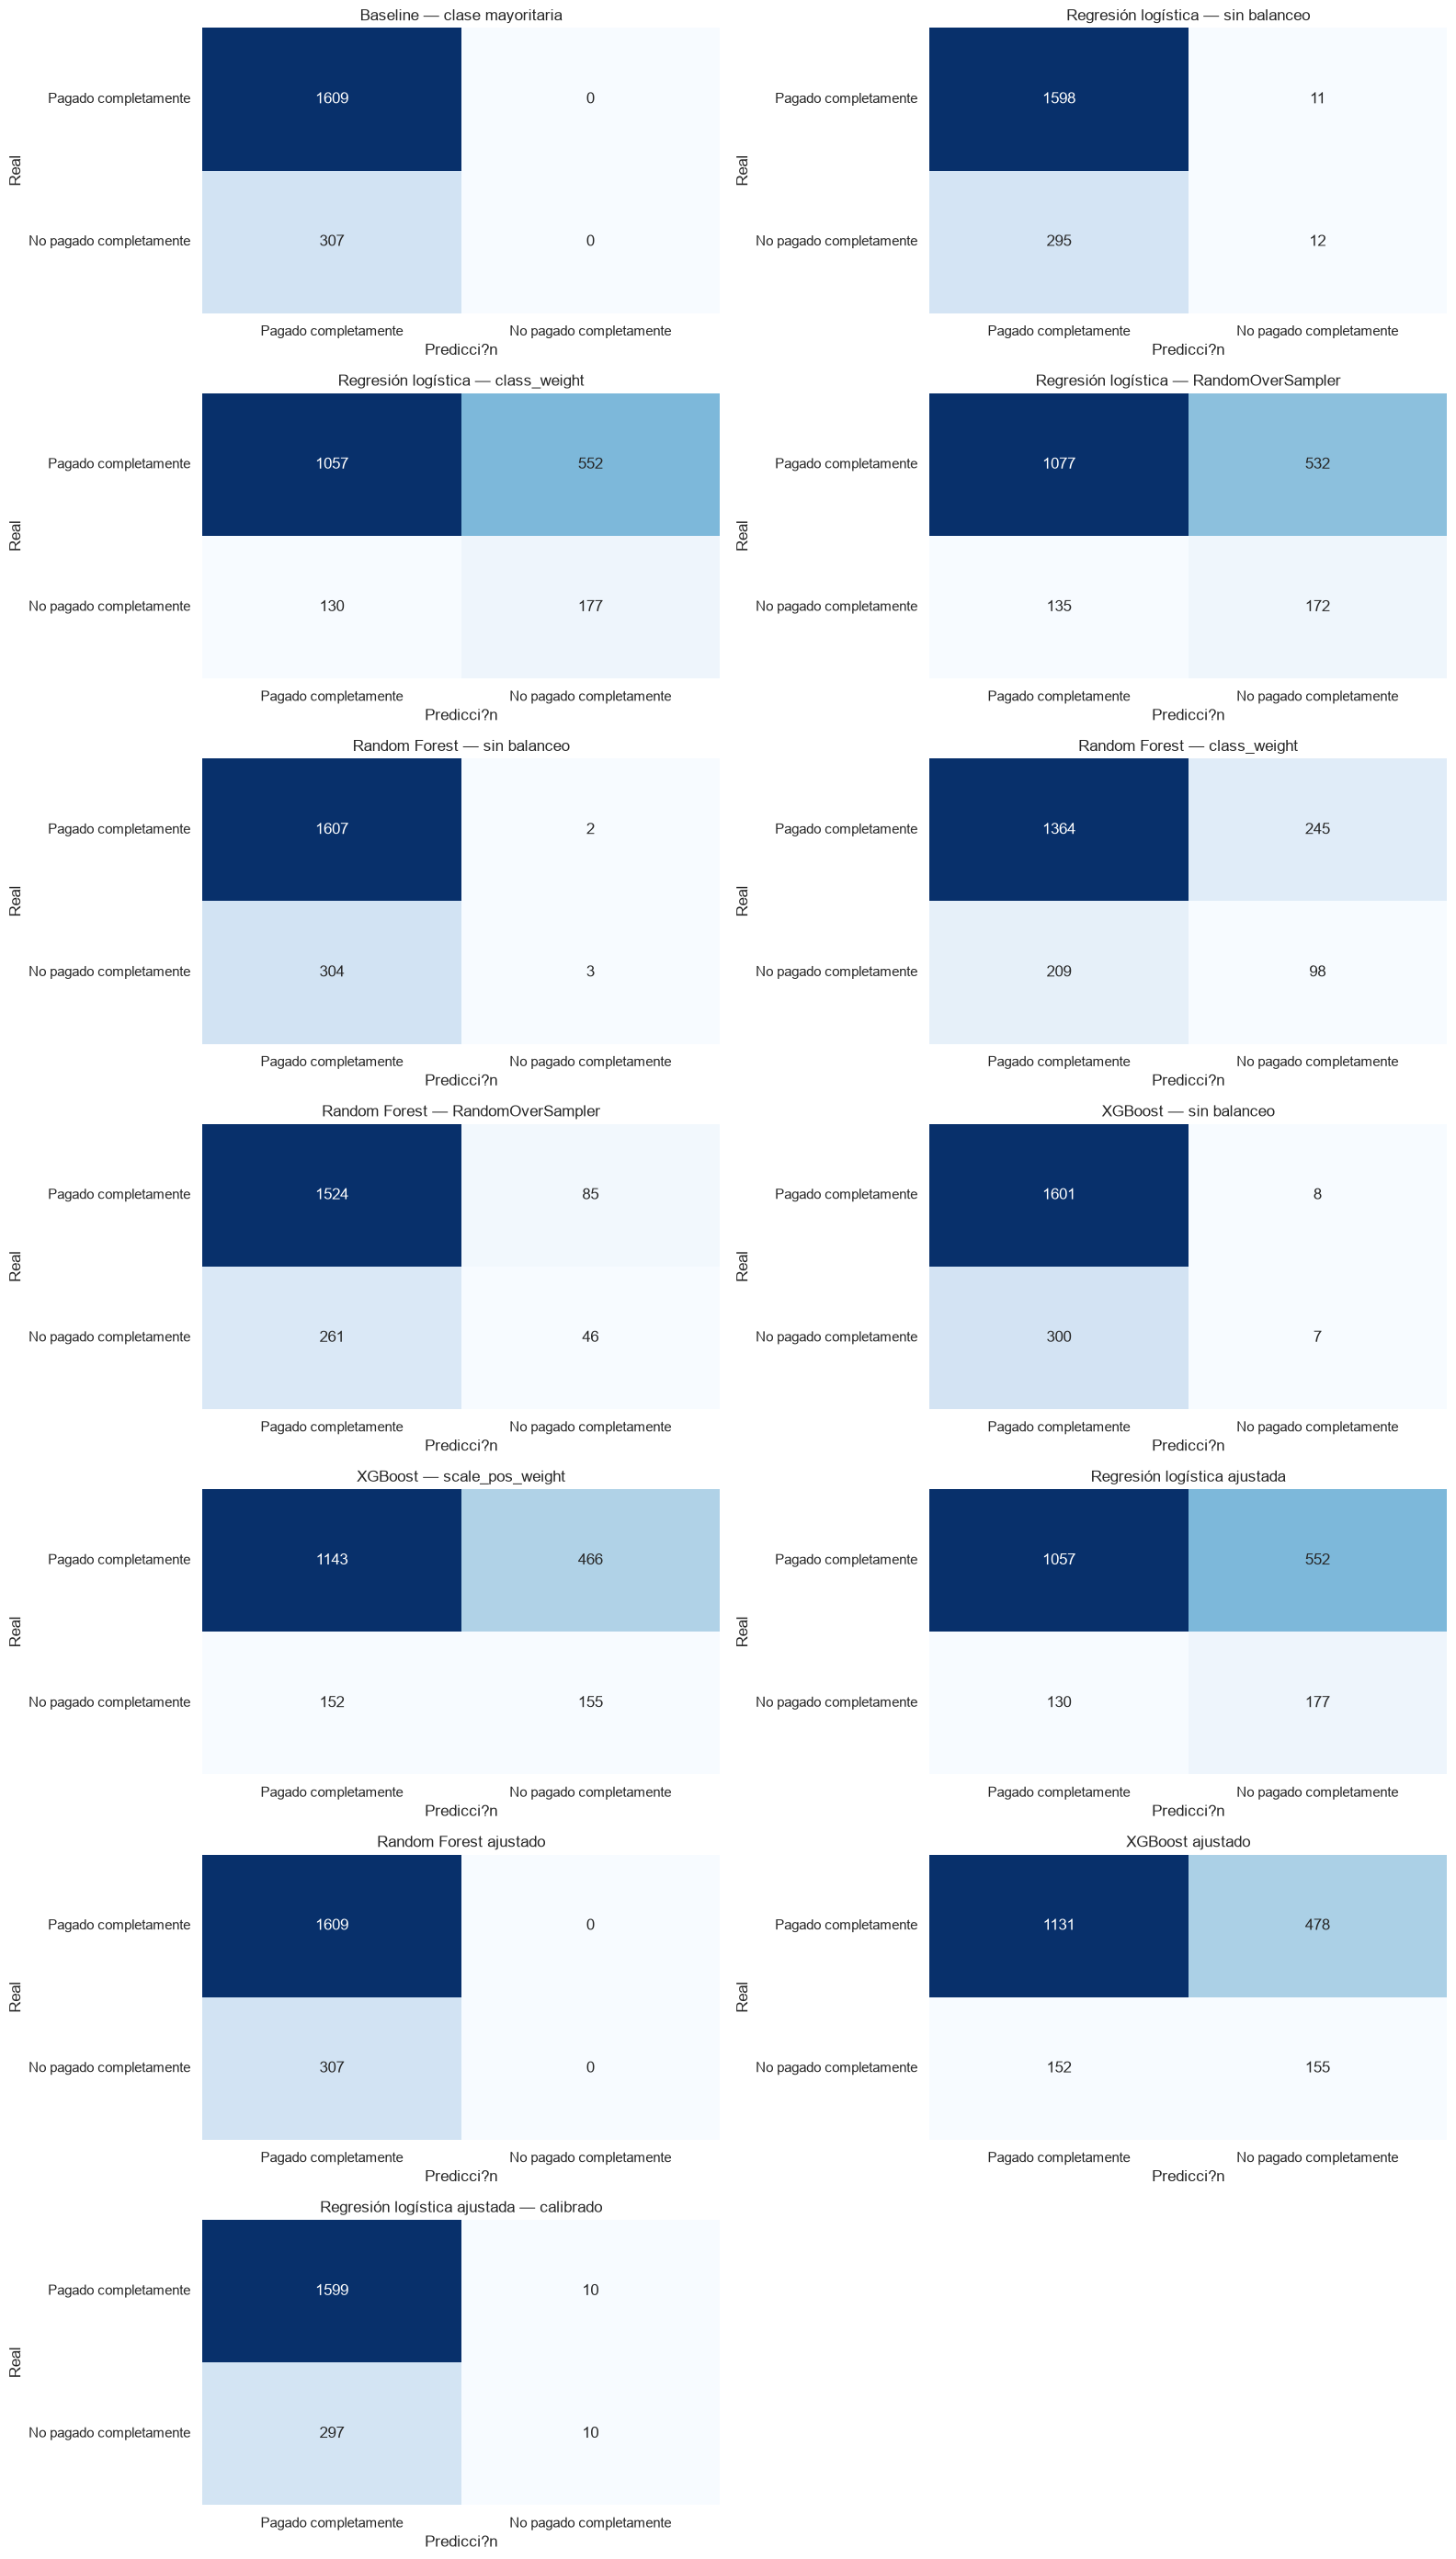

In [23]:

confusion_rows = []
for model_name, model_info in models.items():
    estimator = model_info['estimator']
    y_pred = estimator.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    confusion_rows.append({
        "Modelo": model_name,
        "Balancing": model_info.get("balancing", "-"),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

confusion_summary = pd.DataFrame(confusion_rows).sort_values("Modelo")
display(confusion_summary[["Modelo", "Balancing", "TN", "FP", "FN", "TP"]])

rows = max(1, (len(models) + 1) // 2)
fig, axes = plt.subplots(rows, 2, figsize=(16, 4 * rows), squeeze=False)
axes_flat = axes.flatten()

for ax, (model_name, model_info) in zip(axes_flat, models.items()):
    y_pred = model_info['estimator'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pagado completamente", "No pagado completamente"],
        yticklabels=["Pagado completamente", "No pagado completamente"],
        ax=ax,
        cbar=False,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicci?n")
    ax.set_ylabel("Real")

for ax in axes_flat[len(models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 28. Ajuste del umbral y comparación final

El objetivo de este sistema no es decidir automáticamente si conceder o rechazar un préstamo. El umbral operativo debe depender de la capacidad de revisión del analista y de la tolerancia a falsos positivos. Por ello, el threshold se selecciona usando exclusivamente validación y luego se aplica al conjunto de test sin re-optimizar.

En la práctica, se define una regla del tipo:

`P(not.fully.paid = 1) >= threshold -> enviar a revisión`

`P(not.fully.paid = 1) < threshold -> no enviar a revisión`

Para ilustrar la decisión, se utiliza un escenario operativo hipotético de capacidad de revisión de 1.000 préstamos, adaptado a la muestra disponible. Ese threshold se determina en validación para aproximar la cantidad de alertas presupuestadas, y se cumple la restricción de que el test se usa solo para evaluar el resultado final.

En los resultados de test, se mantiene el análisis de recall, precision, specificity, FN, FP y número de alertas, pero la lectura final se interpreta como apoyo a la revisión analista y no como una decisión automática de crédito.

## Analyst Review Capacity

Como no disponemos de información real sobre la capacidad operativa de un analista, estos escenarios son hipotéticos y sirven para evaluar el trade-off entre cobertura y carga de revisión. La capacidad de revisión se define como el número de préstamos que el analista puede revisar en cada turno o periodo.

Se parte de los escenarios `review_capacities = [500, 750, 1000, 1250, 1500]`, pero se adaptan automáticamente al tamaño real del conjunto de test para no pedir más revisiones de las que existen. Estos valores no representan capacidades reales de LendingClub ni de un equipo de riesgo concreto; son simplemente escenarios de sensibilidad.

,Modelo,Capacidad de revisión,Alertas,TP,FP,FN,TN,Recall,Precision,Specificity,% revisados,% impagos capturados,Impagos capturados
0,Regresión logística — sin balanceo,500,500,135,365,172,1244,0.4397,0.2700,0.7732,0.2610,0.4397,135
1,Regresión logística — sin balanceo,750,750,183,567,124,1042,0.5961,0.2440,0.6476,0.3914,0.5961,183
2,Regresión logística — sin balanceo,1000,1000,225,775,82,834,0.7329,0.2250,0.5183,0.5219,0.7329,225
3,Regresión logística — sin balanceo,1250,1250,257,993,50,616,0.8371,0.2056,0.3828,0.6524,0.8371,257
4,Regresión logística — sin balanceo,1500,1500,286,1214,21,395,0.9316,0.1907,0.2455,0.7829,0.9316,286
5,Regresión logística — RandomOverSampler,500,500,138,362,169,1247,0.4495,0.2760,0.7750,0.2610,0.4495,138
6,Regresión logística — RandomOverSampler,750,750,179,571,128,1038,0.5831,0.2387,0.6451,0.3914,0.5831,179
7,Regresión logística — RandomOverSampler,1000,1000,222,778,85,831,0.7231,0.2220,0.5165,0.5219,0.7231,222
8,Regresión logística — RandomOverSampler,1250,1250,254,996,53,613,0.8274,0.2032,0.3810,0.6524,0.8274,254
9,Regresión logística — RandomOverSampler,1500,1500,287,1213,20,396,0.9349,0.1913,0.2461,0.7829,0.9349,287


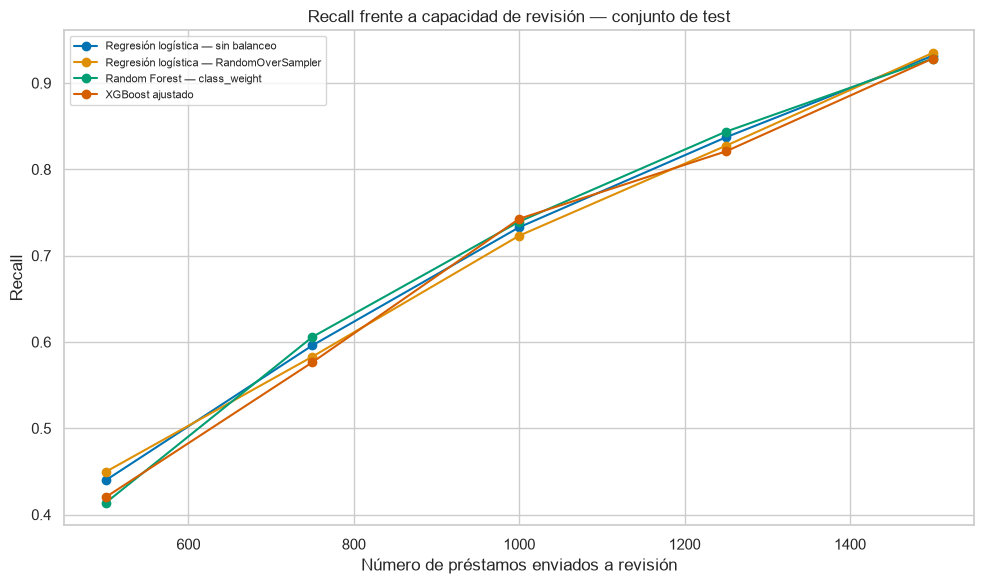

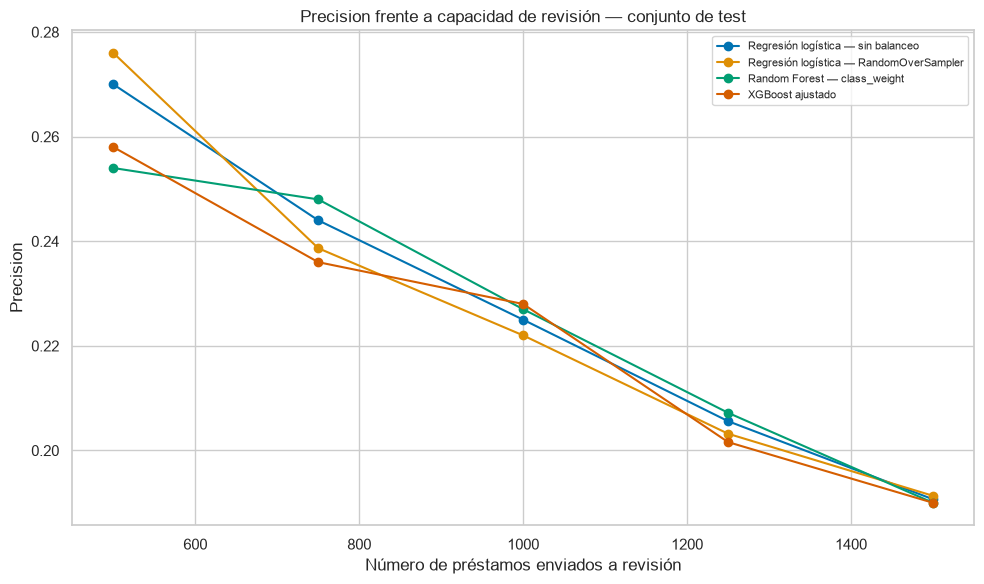

In [24]:
review_capacities = [500, 750, 1000, 1250, 1500]
review_capacities = sorted({min(int(cap), len(y_test)) for cap in review_capacities if int(cap) > 0})
review_capacities = [cap for cap in review_capacities if cap <= len(y_test)]
if not review_capacities:
    review_capacities = [len(y_test)]

primary_candidates = [
    "Regresión logística — sin balanceo",
    "Regresión logística — RandomOverSampler",
    "Random Forest — class_weight",
    "XGBoost ajustado",
]
candidate_models = [name for name in primary_candidates if name in evaluation]

review_rows = []
for model_name in candidate_models:
    probabilities = evaluation[model_name]["probabilities"]
    actuals = y_test.to_numpy()
    sorted_frame = pd.DataFrame({
        "probabilidad": probabilities,
        "real": actuals,
    }).sort_values("probabilidad", ascending=False).reset_index(drop=True)
    total_default_positive = int((actuals == 1).sum())
    total_non_default_negative = int((actuals == 0).sum())
    for capacity in review_capacities:
        selected = sorted_frame.iloc[:capacity]
        tp = int((selected["real"] == 1).sum())
        fp = int((selected["real"] == 0).sum())
        fn = total_default_positive - tp
        tn = total_non_default_negative - fp
        recall_value = tp / (tp + fn) if (tp + fn) else 0.0
        precision_value = tp / (tp + fp) if (tp + fp) else 0.0
        specificity_value = tn / (tn + fp) if (tn + fp) else 0.0
        review_rows.append({
            "Modelo": model_name,
            "Capacidad de revisión": capacity,
            "Alertas": int(tp + fp),
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Recall": recall_value,
            "Precision": precision_value,
            "Specificity": specificity_value,
            "% revisados": capacity / len(y_test),
            "% impagos capturados": recall_value,
            "Impagos capturados": tp,
        })

review_capacity_summary = pd.DataFrame(review_rows)
display(review_capacity_summary.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
for model in candidate_models:
    capacity_values = review_capacity_summary.loc[review_capacity_summary["Modelo"] == model, ["Capacidad de revisión", "Recall"]].sort_values("Capacidad de revisión")
    ax.plot(capacity_values["Capacidad de revisión"], capacity_values["Recall"], marker="o", label=model)
ax.set_title("Recall frente a capacidad de revisión — conjunto de test")
ax.set_xlabel("Número de préstamos enviados a revisión")
ax.set_ylabel("Recall")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for model in candidate_models:
    capacity_values = review_capacity_summary.loc[review_capacity_summary["Modelo"] == model, ["Capacidad de revisión", "Precision"]].sort_values("Capacidad de revisión")
    ax.plot(capacity_values["Capacidad de revisión"], capacity_values["Precision"], marker="o", label=model)
ax.set_title("Precision frente a capacidad de revisión — conjunto de test")
ax.set_xlabel("Número de préstamos enviados a revisión")
ax.set_ylabel("Precision")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


## Operational Threshold Selection

El threshold operativo no se selecciona maximizando F2 sobre el test. En cambio, se define con validación de acuerdo con la capacidad de revisión prevista por el analista. Si una capacidad concreta fuese 1.000 revisiones, el threshold asociado a ese volumen se aplica al test para generar la evaluación final del sistema de apoyo.

In [25]:
def metrics_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    precision_value = precision_score(y_true, predictions, zero_division=0)
    recall_value = recall_score(y_true, predictions, zero_division=0)
    specificity_value = tn / (tn + fp) if (tn + fp) else 0.0
    beta = 2
    f2_value = ((1 + beta**2) * precision_value * recall_value) / (beta**2 * precision_value + recall_value) if (precision_value + recall_value) else 0.0
    return {
        "Precision": precision_value,
        "Recall": recall_value,
        "Specificity": specificity_value,
        "F2": f2_value,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }


review_capacity_target = min(1000, len(y_test))
operational_threshold_rows = []
for model_name in candidate_models:
    estimator = models[model_name]["estimator"]
    validation_probabilities = estimator.predict_proba(X_val)[:, 1]
    ranked_val = pd.DataFrame({
        "probabilidad": validation_probabilities,
        "real": y_val.to_numpy(),
    }).sort_values("probabilidad", ascending=False).reset_index(drop=True)
    if review_capacity_target >= len(ranked_val):
        selected_threshold = 0.0
    else:
        selected_threshold = float(ranked_val.iloc[review_capacity_target - 1]["probabilidad"])
    validation_metrics = metrics_at_threshold(y_val, validation_probabilities, selected_threshold)
    test_probabilities = evaluation[model_name]["probabilities"]
    test_metrics = metrics_at_threshold(y_test, test_probabilities, selected_threshold)
    operational_threshold_rows.append({
        "Modelo": model_name,
        "Capacidad operativa seleccionada": review_capacity_target,
        "Umbral validado": selected_threshold,
        **{f"Validación {key}": value for key, value in validation_metrics.items()},
        **{f"Test {key}": value for key, value in test_metrics.items()},
    })

operational_threshold_summary = pd.DataFrame(operational_threshold_rows)
display(operational_threshold_summary.round(4))

objective_recalls = [0.90, 0.95, 0.98]
recall_goal_rows = []
for model_name in candidate_models:
    validation_probabilities = models[model_name]["estimator"].predict_proba(X_val)[:, 1]
    precision_values, recall_values, candidate_thresholds = precision_recall_curve(y_val, validation_probabilities)
    precision_values = precision_values[1:]
    recall_values = recall_values[1:]
    for target_recall in objective_recalls:
        valid_indices = np.where(recall_values >= target_recall)[0]
        if valid_indices.size == 0:
            recall_goal_rows.append({
                "Modelo": model_name,
                "Objetivo recall": target_recall,
                "Umbral validado": np.nan,
                "Nota": "No alcanzable en validación",
            })
            continue
        chosen_idx = valid_indices[np.argmin(np.abs(recall_values[valid_indices] - target_recall))]
        threshold = float(candidate_thresholds[chosen_idx])
        test_metrics = metrics_at_threshold(y_test, evaluation[model_name]["probabilities"], threshold)
        recall_goal_rows.append({
            "Modelo": model_name,
            "Objetivo recall": target_recall,
            "Umbral validado": threshold,
            "Recall (test)": test_metrics["Recall"],
            "Precision (test)": test_metrics["Precision"],
            "Specificity (test)": test_metrics["Specificity"],
            "FP (test)": test_metrics["FP"],
            "FN (test)": test_metrics["FN"],
            "Alertas (test)": test_metrics["TP"] + test_metrics["FP"],
            "Nota": "",
        })

recall_goals_summary = pd.DataFrame(recall_goal_rows)
display(recall_goals_summary.round(4))


,Modelo,Capacidad operativa seleccionada,Umbral validado,Validación Precision,Validación Recall,Validación Specificity,Validación F2,Validación TN,Validación FP,Validación FN,Validación TP,Test Precision,Test Recall,Test Specificity,Test F2,Test TN,Test FP,Test FN,Test TP
0,Regresión logística — sin balanceo,1000,0.1326,0.2240,0.7296,0.5177,0.5027,833,776,83,224,0.2253,0.7134,0.5320,0.4977,856,753,88,219
1,Regresión logística — RandomOverSampler,1000,0.4358,0.2230,0.7264,0.5171,0.5004,832,777,84,223,0.2221,0.7199,0.5190,0.4971,835,774,86,221
2,Random Forest — class_weight,1000,0.3351,0.2150,0.7003,0.5121,0.4825,824,785,92,215,0.2272,0.7296,0.5264,0.5059,847,762,83,224
3,XGBoost ajustado,1000,0.4354,0.2220,0.7231,0.5165,0.4982,831,778,85,222,0.2293,0.7134,0.5426,0.5016,873,736,88,219


,Modelo,Objetivo recall,Umbral validado,Recall (test),Precision (test),Specificity (test),FP (test),FN (test),Alertas (test),Nota
0,Regresión logística — sin balanceo,0.9000,0.1000,0.8990,0.1988,0.3089,1112,31,1388,
1,Regresión logística — sin balanceo,0.9500,0.0848,0.9446,0.1875,0.2188,1257,17,1547,
2,Regresión logística — sin balanceo,0.9800,0.0652,0.9902,0.1733,0.0988,1450,3,1754,
3,Regresión logística — RandomOverSampler,0.9000,0.3510,0.9153,0.2004,0.3033,1121,26,1402,
4,Regresión logística — RandomOverSampler,0.9500,0.3045,0.9414,0.1848,0.2076,1275,18,1564,
5,Regresión logística — RandomOverSampler,0.9800,0.2580,0.9805,0.1754,0.1206,1415,6,1716,
6,Random Forest — class_weight,0.9000,0.2193,0.9349,0.1855,0.2169,1260,20,1547,
7,Random Forest — class_weight,0.9500,0.1719,0.9772,0.1769,0.1324,1396,7,1696,
8,Random Forest — class_weight,0.9800,0.1518,0.9870,0.1749,0.1119,1429,4,1732,
9,XGBoost ajustado,0.9000,0.3509,0.8893,0.1920,0.2859,1149,34,1422,
